# Imported Libs

In [394]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder \
, StandardScaler, FunctionTransformer, PowerTransformer, Normalizer, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge \
, Lasso, ElasticNet, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_score \
,GridSearchCV, KFold, RepeatedKFold, StratifiedKFold, ShuffleSplit, StratifiedShuffleSplit \
, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import RFE

from scipy import stats
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

%matplotlib inline

# Exploratory Data Analysis

In [395]:
#get data
df_train = pd.read_csv('./data/train.csv')
df_test = pd.read_csv('./data/test.csv')

In [396]:
#data shape
df_train.shape

(1460, 81)

In [397]:
#sneakpeak at data
df_train.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [398]:
#check data and dtypes
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [399]:
#get data summary info
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [400]:
#make copy of data to work with
df_train_copy = df_train.copy()

In [401]:
#divide dataset to get numerical and categorical data
def num_cat_divider(df):
    numerical = df.select_dtypes(include='number').drop('Id', axis=1)
    categorical = df.select_dtypes(exclude='number')
    return numerical, categorical

numerical, categorical = num_cat_divider(df_train_copy)

In [402]:
#make outliers detector
def outliers_detection(df, columns):
    outliers = []
    for column in columns:
        std= df[column].std()
        mean= df[column].mean()
        outlier_data= df[(df[column] > mean + 2 * std) |
                         (df[column] < mean - 2 * std)]
        outliers.append(outlier_data[column].count())
    return outliers

In [403]:
#describe numerical data
def num_data_describer(df ,num_data):
    num_data_desc = pd.DataFrame(index=list(num_data))
    num_data_desc['type'] = num_data.dtypes
    num_data_desc['count'] = num_data.count()
    num_data_desc['nunique'] = num_data.nunique()
    num_data_desc['%unique'] = num_data_desc['nunique'] / len(num_data) * 100
    num_data_desc['null'] = num_data.isnull().sum()
    num_data_desc['%null'] = num_data_desc['null'] / len(num_data) * 100
    num_data_desc['min'] = num_data.min()
    num_data_desc['max'] = num_data.max()
    num_data_desc['mean'] = num_data.mean()
    num_data_desc['median'] = num_data.median()
    num_data_desc['std'] = num_data.std()
    num_data_desc['outliers'] = outliers_detection(df,list(num_data))
    num_data_desc['%outliers'] = num_data_desc['outliers'] / len(num_data) * 100
    return num_data_desc

num_data_described = num_data_describer(df_train_copy, numerical)
num_data_described

,type,count,nunique,%unique,null,%null,min,max,mean,median,std,outliers,%outliers
MSSubClass,int64,1460,15,1.027397,0,0.000000,20.0,190.0,56.897260,50.0,42.300571,103,7.054795
LotFrontage,float64,1201,110,7.534247,259,17.739726,21.0,313.0,70.049958,69.0,24.284752,60,4.109589
LotArea,int64,1460,1073,73.493151,0,0.000000,1300.0,215245.0,10516.828082,9478.5,9981.264932,22,1.506849
OverallQual,int64,1460,10,0.684932,0,0.000000,1.0,10.0,6.099315,6.0,1.382997,86,5.890411
OverallCond,int64,1460,9,0.616438,0,0.000000,1.0,9.0,5.575342,5.0,1.112799,125,8.561644
YearBuilt,int64,1460,112,7.671233,0,0.000000,1872.0,2010.0,1971.267808,1973.0,30.202904,47,3.219178
YearRemodAdd,int64,1460,61,4.178082,0,0.000000,1950.0,2010.0,1984.865753,1994.0,20.645407,0,0.000000
MasVnrArea,float64,1452,327,22.397260,8,0.547945,0.0,1600.0,103.685262,0.0,181.066207,68,4.657534
BsmtFinSF1,int64,1460,637,43.630137,0,0.000000,0.0,5644.0,443.639726,383.5,456.098091,48,3.287671
BsmtFinSF2,int64,1460,144,9.863014,0,0.000000,0.0,1474.0,46.549315,0.0,161.319273,82,5.616438


In [404]:
#describe categorical data
def cat_data_describer(cat_data):
    cat_data_desc = pd.DataFrame(index = list(cat_data))
    cat_data_desc['type'] = cat_data.dtypes
    cat_data_desc['count'] = cat_data.count()
    cat_data_desc['nunique'] = cat_data.nunique()
    cat_data_desc['%unique'] = cat_data_desc['nunique'] / len(cat_data) * 100
    cat_data_desc['null'] = cat_data.isnull().sum()
    cat_data_desc['%null'] = cat_data_desc['null'] / len(cat_data) * 100
    return cat_data_desc

cat_data_described = cat_data_describer(categorical)
cat_data_described

,type,count,nunique,%unique,null,%null
MSZoning,object,1460,5,0.342466,0,0.000000
Street,object,1460,2,0.136986,0,0.000000
Alley,object,91,2,0.136986,1369,93.767123
LotShape,object,1460,4,0.273973,0,0.000000
LandContour,object,1460,4,0.273973,0,0.000000
Utilities,object,1460,2,0.136986,0,0.000000
LotConfig,object,1460,5,0.342466,0,0.000000
LandSlope,object,1460,3,0.205479,0,0.000000
Neighborhood,object,1460,25,1.712329,0,0.000000
Condition1,object,1460,9,0.616438,0,0.000000


Skewness: 1.8828757597682129
Kurtosis: 6.536281860064529


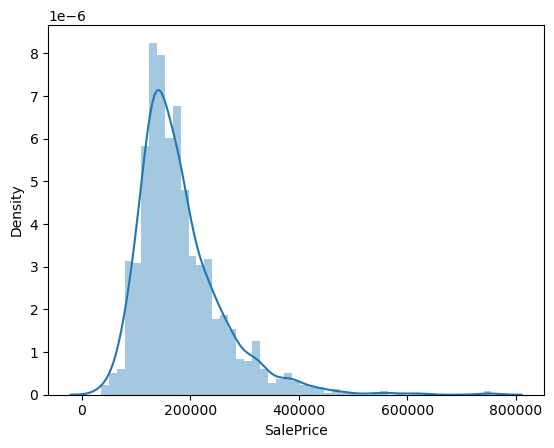

In [405]:
#quick look at target feature
sns.distplot(df_train_copy['SalePrice'])

print(f'Skewness: {df_train_copy.SalePrice.skew()}')
print(f'Kurtosis: {df_train_copy.SalePrice.kurt()}')

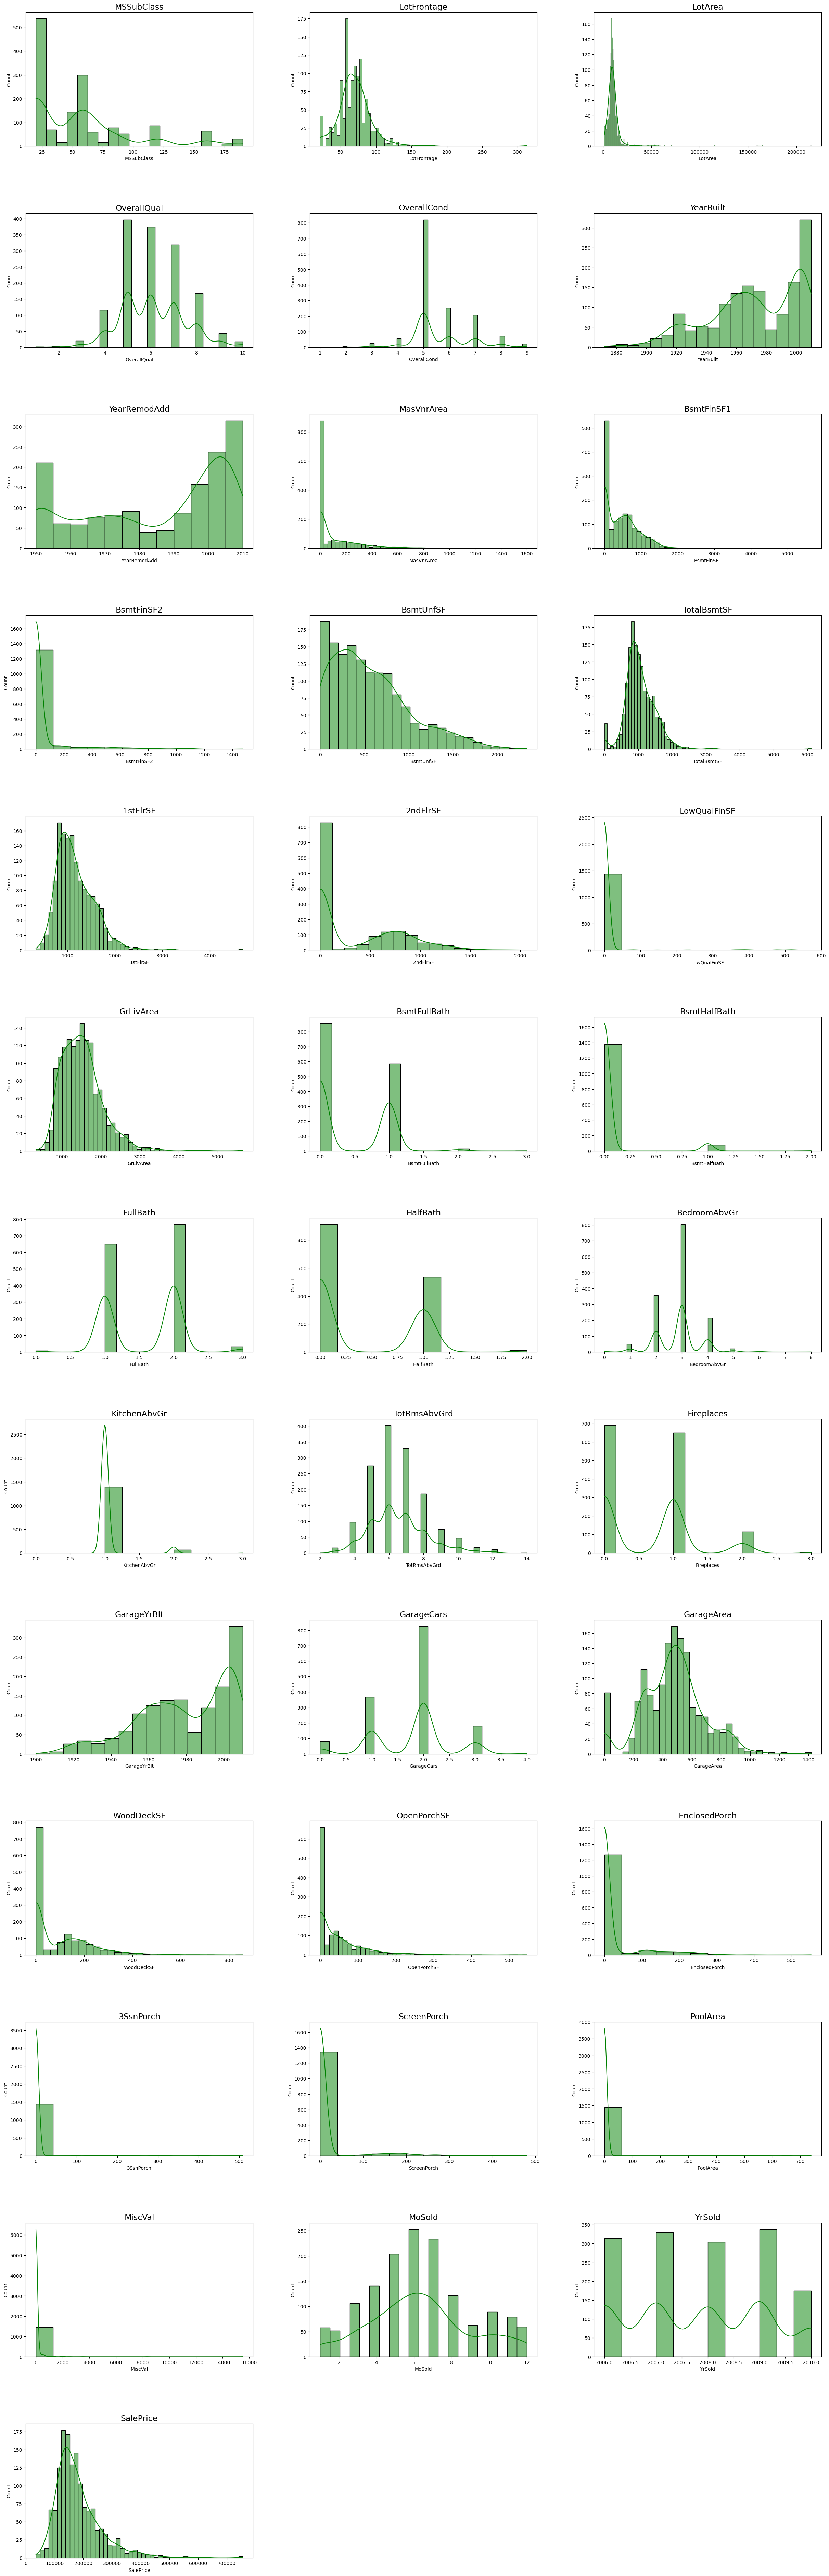

In [406]:
#visualize numerical data
plt.figure(figsize=(30,150))
plt.subplots_adjust(hspace=0.5, wspace=0.25)
for n, col in enumerate(list(numerical)):
    plt.subplot(20,3,n+1)
    sns.histplot(df_train_copy[col], color='green', kde=True)
    plt.title(col, fontsize=17)
plt.show()

In [407]:
#check correlations (numerical)
num_corr = numerical.corr()
num_corr_w_saleprice = num_corr.sort_values(by='SalePrice', ascending=False)['SalePrice'][:]
num_corr_w_saleprice

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

<AxesSubplot: >

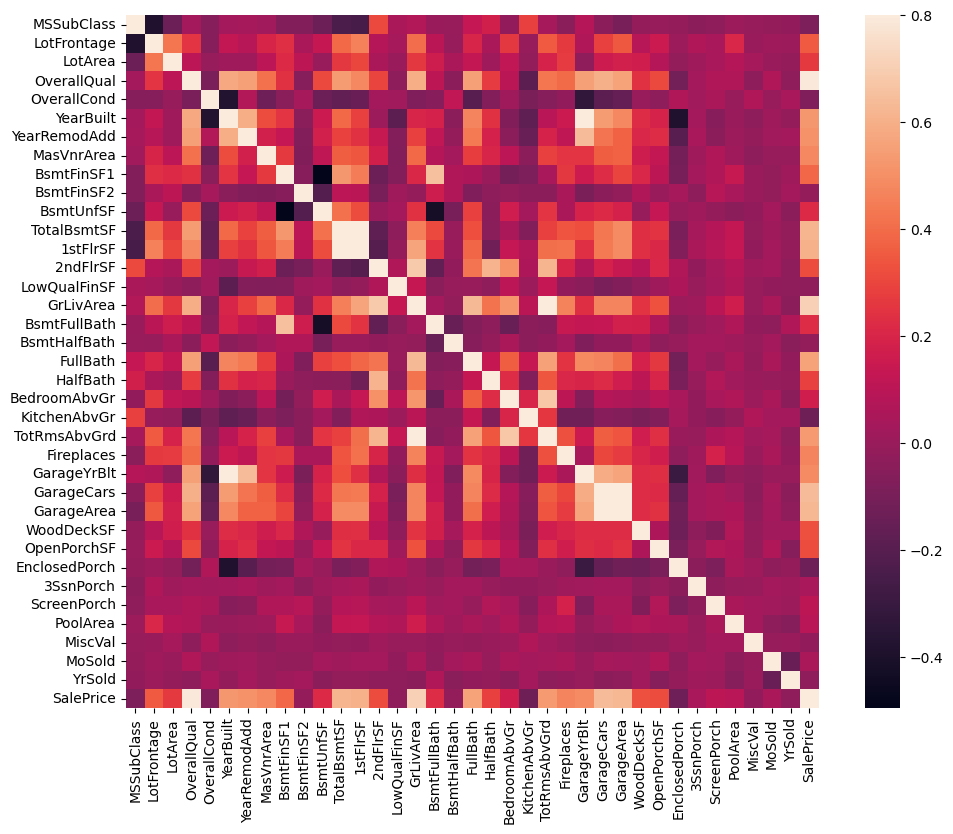

In [408]:
#numerical correlations matrix
f, ax = plt.subplots(figsize=(12,9))
sns.heatmap(num_corr, vmax=.8, square=True)

In [409]:
#check correlations (categorical)
categorical.columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [410]:
#set ordinal or nominal type
ord_or_nom = {
 'MSZoning':'nom',
 'Street':'nom',
 'Alley':'nom',
 'LotShape':'ord',
 'LandContour':'nom',
 'Utilities':'ord',
 'LotConfig':'nom',
 'LandSlope':'ord',
 'Neighborhood':'nom',
 'Condition1':'nom',
 'Condition2':'nom',
 'BldgType':'nom',
 'HouseStyle':'nom',
 'RoofStyle':'nom',
 'RoofMatl':'nom',
 'Exterior1st':'nom',
 'Exterior2nd':'nom',
 'MasVnrType':'nom',
 'ExterQual':'ord',
 'ExterCond':'ord',
 'Foundation':'nom',
 'BsmtQual':'ord',
 'BsmtCond':'ord',
 'BsmtExposure':'ord',
 'BsmtFinType1':'nom',
 'BsmtFinType2':'ord',
 'Heating':'nom',
 'HeatingQC':'ord',
 'CentralAir':'nom',
 'Electrical':'nom',
 'KitchenQual':'ord',
 'Functional':'nom',
 'FireplaceQu':'ord',
 'GarageType':'nom',
 'GarageFinish':'ord',
 'GarageQual':'ord',
 'GarageCond':'ord',
 'PavedDrive':'nom',
 'PoolQC':'ord',
 'Fence':'ord',
 'MiscFeature':'nom',
 'SaleType':'nom',
 'SaleCondition':'nom'
}

In [411]:
def nominal_or_ordinal(categorical_df,type_dict):
    label_encoded_cat = categorical_df.copy()
    
    le = LabelEncoder()
    oe = OrdinalEncoder()
    
    ordinals = [i for i in type_dict.keys() if type_dict[i] == 'ord']
    nominals = [i for i in type_dict.keys() if type_dict[i] == 'nom']
    
    for col in nominals:
        label_encoded_cat[col]=le.fit_transform(label_encoded_cat[col])
    
    label_encoded_cat[ordinals]=oe.fit_transform(label_encoded_cat[ordinals])

    return label_encoded_cat
    

In [412]:
categorical_encoded = nominal_or_ordinal(categorical, ord_or_nom)
categorical_encoded_with_saleprice = categorical_encoded.join(df_train_copy['SalePrice'])

In [413]:
cat_corr = categorical_encoded_with_saleprice.corr()
cat_corr_w_saleprice = cat_corr.sort_values(by='SalePrice', ascending=False)['SalePrice'][:]
cat_corr_w_saleprice

SalePrice        1.000000
Foundation       0.382479
CentralAir       0.251328
Electrical       0.234716
PavedDrive       0.231357
RoofStyle        0.222405
SaleCondition    0.213092
Neighborhood     0.210851
HouseStyle       0.180163
GarageCond       0.150576
Alley            0.139868
RoofMatl         0.132383
ExterCond        0.117303
Functional       0.115328
GarageQual       0.115119
Exterior2nd      0.103766
Exterior1st      0.103551
Condition1       0.091155
MiscFeature      0.073609
BsmtCond         0.060362
LandSlope        0.051152
BsmtFinType2     0.041161
Street           0.041036
MasVnrType       0.029658
LandContour      0.015453
Condition2       0.007513
Utilities       -0.014314
SaleType        -0.054911
LotConfig       -0.067396
BldgType        -0.085591
Heating         -0.098812
BsmtFinType1    -0.103114
FireplaceQu     -0.166817
MSZoning        -0.166872
Fence           -0.172999
LotShape        -0.255580
BsmtExposure    -0.285290
HeatingQC       -0.400178
GarageType  

<AxesSubplot: >

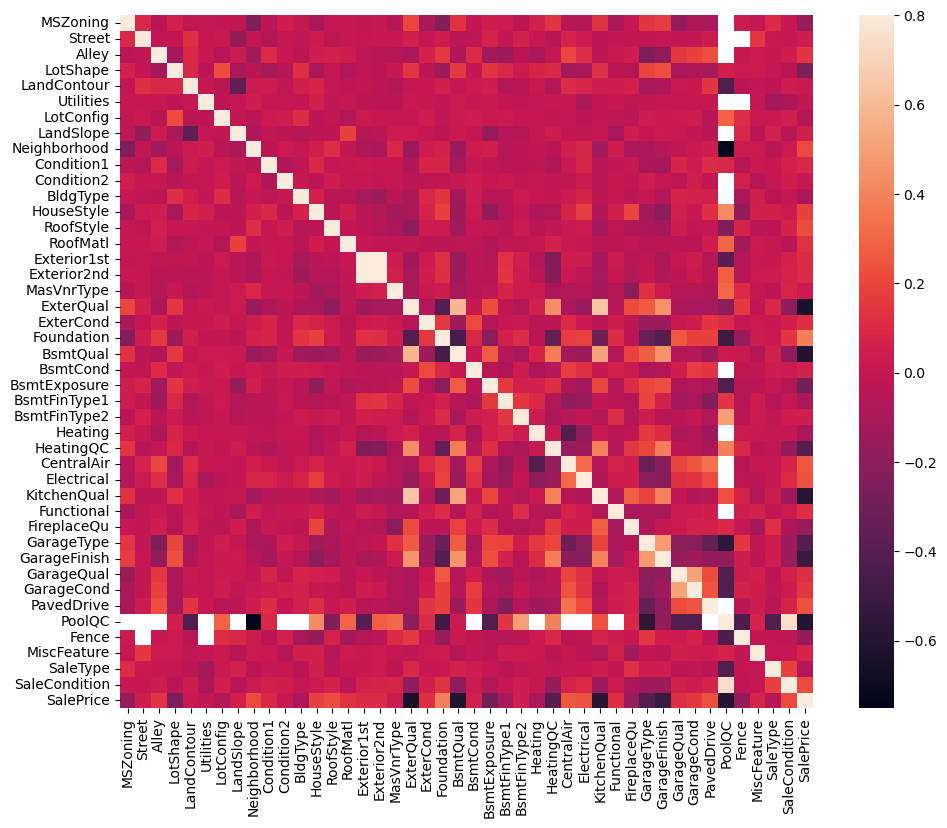

In [414]:
#categorical correlations matrix
f, ax = plt.subplots(figsize=(12,9))
sns.heatmap(cat_corr, vmax=.8, square=True)

In [415]:
#columns correlation with saleprice
num_corr_without_saleprice = num_corr_w_saleprice.to_frame().drop('SalePrice',axis=0)
cat_corr_without_saleprice = cat_corr_w_saleprice.to_frame().drop('SalePrice',axis=0)
feature_saleprice_corr = pd.concat([num_corr_without_saleprice,cat_corr_without_saleprice])
feature_saleprice_corr

,SalePrice
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
...,...
GarageFinish,-0.513105
KitchenQual,-0.589189
PoolQC,-0.595229
BsmtQual,-0.611179


In [416]:
#look at columns description and define its importance
importance_of_features_dict = {
 'MSSubClass':'low',
 'MSZoning':'medium',
 'LotFrontage':'low',
 'LotArea':'high',
 'Street':'low',
 'Alley':'low',
 'LotShape':'low',
 'LandContour':'medium',
 'Utilities':'medium',
 'LotConfig':'low',
 'LandSlope':'medium',
 'Neighborhood':'low',
 'Condition1':'low',
 'Condition2':'low',
 'BldgType':'medium',
 'HouseStyle':'medium',
 'OverallQual':'medium',
 'OverallCond':'high',
 'YearBuilt':'high',
 'YearRemodAdd':'low',
 'RoofStyle':'low',
 'RoofMatl':'low',
 'Exterior1st':'low',
 'Exterior2nd':'low',
 'MasVnrType':'low',
 'MasVnrArea':'low',
 'ExterQual':'low',
 'ExterCond':'medium',
 'Foundation':'medium',
 'BsmtQual':'medium',
 'BsmtCond':'medium',
 'BsmtExposure':'low',
 'BsmtFinType1':'low',
 'BsmtFinSF1':'low',
 'BsmtFinType2':'low',
 'BsmtFinSF2':'low',
 'BsmtUnfSF':'low',
 'TotalBsmtSF':'high',
 'Heating':'medium',
 'HeatingQC':'low',
 'CentralAir':'low',
 'Electrical':'low',
 '1stFlrSF':'low',
 '2ndFlrSF':'low',
 'LowQualFinSF':'low',
 'GrLivArea':'high',
 'BsmtFullBath':'low',
 'BsmtHalfBath':'low',
 'FullBath':'low',
 'HalfBath':'low',
 'BedroomAbvGr':'low',
 'KitchenAbvGr':'low',
 'KitchenQual':'low',
 'TotRmsAbvGrd':'low',
 'Functional':'low',
 'Fireplaces':'low',
 'FireplaceQu':'low',
 'GarageType':'medium',
 'GarageYrBlt':'low',
 'GarageFinish':'low',
 'GarageCars':'low',
 'GarageArea':'medium',
 'GarageQual':'low',
 'GarageCond':'medium',
 'PavedDrive':'low',
 'WoodDeckSF':'low',
 'OpenPorchSF':'low',
 'EnclosedPorch':'low',
 '3SsnPorch':'low',
 'ScreenPorch':'low',
 'PoolArea':'low',
 'PoolQC':'low',
 'Fence':'low',
 'MiscFeature':'low',
 'MiscVal':'low',
 'MoSold':'low',
 'YrSold':'low',
 'SaleType':'low',
 'SaleCondition':'low'
}

In [417]:
#make dataframe for importance
importance_of_features = pd.DataFrame.from_dict(importance_of_features_dict,orient='index', columns=['importance'])
importance_of_features

,importance
MSSubClass,low
MSZoning,medium
LotFrontage,low
LotArea,high
Street,low
...,...
MiscVal,low
MoSold,low
YrSold,low
SaleType,low


In [418]:
#correlation and column importance
importance_of_features_full = importance_of_features.join(feature_saleprice_corr)
importance_of_features_full.rename(columns={'SalePrice':'corr_with_saleprice'}, inplace=True)
importance_of_features_full.sort_values(by=['corr_with_saleprice'], ascending=False, inplace=True)
importance_of_features_full['feature_type'] = None
importance_of_features_full.loc[list(categorical),'feature_type'] = 'cat'
importance_of_features_full.loc[importance_of_features_full['feature_type'].isna(),'feature_type'] = 'num'
importance_of_features_full

,importance,corr_with_saleprice,feature_type
OverallQual,medium,0.790982,num
GrLivArea,high,0.708624,num
GarageCars,low,0.640409,num
GarageArea,medium,0.623431,num
TotalBsmtSF,high,0.613581,num
...,...,...,...
GarageFinish,low,-0.513105,cat
KitchenQual,low,-0.589189,cat
PoolQC,low,-0.595229,cat
BsmtQual,medium,-0.611179,cat


# Data wrangling 

In [419]:
#data to prototype
df_to_handle = df_train_copy.copy()

In [420]:
#deal with outliers
def gentle_with_outliers(df):
    
    outliers_index = []
    for col in list(df):
        outliers_index.extend(list(df[col].nlargest(2).index))
        outliers_index.extend(list(df[col].nsmallest(2).index))
    return list(set(outliers_index))      

df_to_handle = df_to_handle.drop(gentle_with_outliers(numerical),axis=0)

In [421]:
#show and handle missing values
def describe_missing_data(df):
    columns_with_missing_values = df.columns[df.isnull().any()]
    df_columns_with_missing_values = df[columns_with_missing_values]
    desc_missing_data = pd.DataFrame(index = list(df_columns_with_missing_values))
    desc_missing_data['type'] = df_columns_with_missing_values.dtypes
    desc_missing_data['count'] = df_columns_with_missing_values.count()
    desc_missing_data['nunique'] = df_columns_with_missing_values.nunique()
    desc_missing_data['%unique'] = desc_missing_data['nunique'] / len(df_columns_with_missing_values) * 100
    desc_missing_data['null'] = df_columns_with_missing_values.isnull().sum()
    desc_missing_data['%null'] = desc_missing_data['null'] / len(df_columns_with_missing_values) * 100
    return desc_missing_data

described_missing_data = describe_missing_data(df_to_handle).join(importance_of_features_full['corr_with_saleprice'])
described_missing_data

,type,count,nunique,%unique,null,%null,corr_with_saleprice
LotFrontage,float64,1130,106,7.697894,247,17.937545,0.351799
Alley,object,84,2,0.145243,1293,93.899782,0.139868
MasVnrType,object,1369,4,0.290487,8,0.580973,0.029658
MasVnrArea,float64,1369,311,22.585330,8,0.580973,0.477493
BsmtQual,object,1344,4,0.290487,33,2.396514,-0.611179
BsmtCond,object,1344,4,0.290487,33,2.396514,0.060362
BsmtExposure,object,1343,4,0.290487,34,2.469136,-0.285290
BsmtFinType1,object,1344,6,0.435730,33,2.396514,-0.103114
BsmtFinType2,object,1344,6,0.435730,33,2.396514,0.041161
Electrical,object,1376,5,0.363108,1,0.072622,0.234716


***Columns handling and filling missing data***

In [422]:
#handle FireplaceQu
df_to_handle.loc[df_to_handle['FireplaceQu'].isna(),'FireplaceQu'] = 'NoFireplace'

In [423]:
#handle PoolQC
df_to_handle.loc[df_to_handle['PoolQC'].isna(),'PoolQC'] = 'NoPool'

In [424]:
#handle Fence
df_to_handle.loc[df_to_handle['Fence'].isna(),'Fence'] = 'NoFence'

In [425]:
#handle MiscFeature
df_to_handle.loc[df_to_handle['MiscFeature'].isna(),'MiscFeature'] = 'NoMiscFeature'

In [426]:
#handle Garage
garage_features_cat = ['GarageType','GarageFinish','GarageCars',
                       'GarageQual','GarageCond']

garage_features_nom = ['GarageYrBlt']

df_to_handle.loc[df_to_handle['GarageType'].isna(),garage_features_cat] = 'NoGarage'
df_to_handle.loc[df_to_handle['GarageYrBlt'].isna(),garage_features_nom] = 0
df_to_handle.loc[df_to_handle['GarageArea'].isna(),'GarageArea'] = 0

In [427]:
#handle Basement
basement_features= ['BsmtQual',
                    'BsmtCond',
                    'BsmtExposure',
                    'BsmtFinType1',
                    'BsmtFinType2']
missing_basement_index = df_to_handle.loc[df_to_handle['BsmtQual'].isna()].index
df_to_handle.loc[missing_basement_index, basement_features] = 'NoBasement'

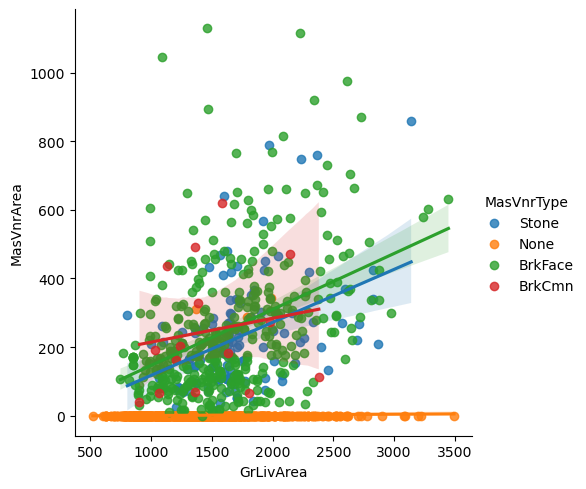

In [428]:
#handle MasVnrArea
sns.lmplot(x='GrLivArea', y='MasVnrArea', hue='MasVnrType', data=df_to_handle)

In [429]:
#get ratio GrLivArea/MasVnrArea but use median? or mean?
ratio_mean = df_to_handle['GrLivArea'].mean() / df_to_handle['MasVnrArea'].mean()


non_zero_median = list(df_to_handle.loc[df_to_handle['MasVnrArea']>0,:].index)
mas_vnr_area_median = df_to_handle.loc[non_zero_median,'MasVnrArea'].median()
ratio_median = df_to_handle['GrLivArea'].median() / mas_vnr_area_median

print(f'ratio_mean: {ratio_mean}')
print(f'ratio_median: {ratio_median}')

ratio_mean: 15.028616361326124
ratio_median: 7.28


In [430]:
#apply ratio
df_to_handle.loc[df_to_handle['MasVnrArea'].isna(), 'MasVnrArea'] = df_to_handle['GrLivArea'] / ratio_median

In [431]:
#handle MasVnrType
df_to_handle.loc[df_to_handle['MasVnrType'].isna(),'MasVnrType'] = 'NoMasVnrType'

<AxesSubplot: xlabel='LotArea', ylabel='LotFrontage'>

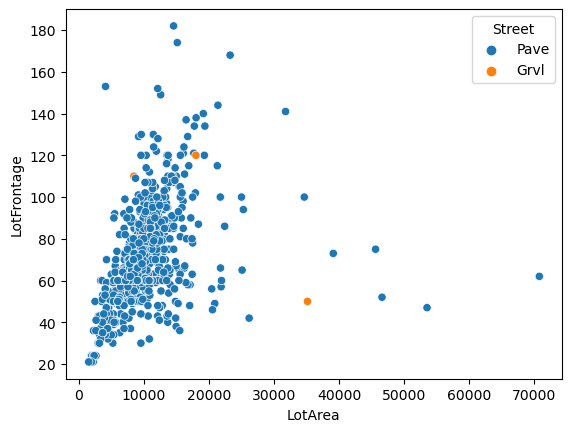

In [432]:
#handle LotFrontage
sns.scatterplot(x=df_to_handle['LotArea'], y=df_to_handle['LotFrontage'], hue=df_to_handle['Street'])

In [433]:
lot_frontage_to_handle = df_to_handle[['LotArea','LotFrontage']]
lot_frontage_missing = list(lot_frontage_to_handle.loc[lot_frontage_to_handle['LotFrontage'].isna()].index)
lot_frontage_to_train = lot_frontage_to_handle.drop(lot_frontage_missing, axis=0)
lot_frontage_to_predict = lot_frontage_to_handle.loc[lot_frontage_missing,:]

In [434]:
features_train = lot_frontage_to_train[['LotArea']]
target_train = lot_frontage_to_train[['LotFrontage']]

lin_reg = LinearRegression()
lin_reg.fit(features_train, target_train)

LinearRegression()

In [435]:
predictions = lin_reg.predict(lot_frontage_to_predict[['LotArea']])
predicted_data = lot_frontage_to_predict.copy()
predicted_data['LotFrontage']=predictions

In [436]:
predicted_data

,LotArea,LotFrontage
7,10382,71.002213
12,12968,76.634980
14,10920,72.174072
31,8544,66.998722
42,9180,68.384043
...,...,...
1429,12546,75.715789
1431,4928,59.122433
1441,4426,58.028988
1443,8854,67.673957


In [437]:
df_to_handle.loc[df_to_handle['LotFrontage'].isna(),'LotFrontage'] = predictions

In [438]:
#handle Alley
df_to_handle = df_to_handle.drop('Alley', axis=1)

In [439]:
#small amounts of missing data handle with SimpleImputer
describe_missing_data(df_to_handle)

,type,count,nunique,%unique,null,%null
BsmtExposure,object,1376,5,0.363108,1,0.072622
Electrical,object,1376,5,0.363108,1,0.072622


In [440]:
#handle rest of missing data
def get_and_fill_rest_of_missing_data(df):
    num_fill = df.select_dtypes(include=['int64','float64']).columns
    cat_fill = df.select_dtypes(include=['object']).columns
    
    num_imputer = SimpleImputer(strategy='mean')
    cat_imputer = SimpleImputer(strategy='most_frequent')
    
    df[num_fill] = num_imputer.fit_transform(df[num_fill])
    df[cat_fill] = cat_imputer.fit_transform(df[cat_fill])
    
get_and_fill_rest_of_missing_data(df_to_handle)

In [441]:
#all missing data handled
describe_missing_data(df_to_handle)

,type,count,nunique,%unique,null,%null


***Data transformations***

In [442]:
#drop outliers(2 highest and 2 lowest values)
# def outlier_dropper(df,n):
#     ids = []
#     numerical = list(df.select_dtypes('number').columns)
#     for col in numerical:
#         upper = list(df[col].nlargest(n).index)
#         lower = list(df[col].nsmallest(n).index)
#         ids.extend(upper)
#         ids.extend(lower)
#     to_drop = list(set(ids))
#     final_data = df.drop(to_drop,axis=0)
#     return final_data

# df_to_handle = outlier_dropper(df_to_handle,2)

In [443]:
#remodel date columns like yearbuilt,yearremodadd,yrsold,mosold,garageyrbuilt
df_to_handle['Age_YearBuilt']=2024-df_to_handle['YearBuilt']
df_to_handle['Age_YearRemodAdd']=2024-df_to_handle['YearRemodAdd']
df_to_handle['Age_YrSold']=2024-df_to_handle['YrSold']
df_to_handle['Age_GarageYrBlt']=2024-df_to_handle['GarageYrBlt']

df_to_handle = df_to_handle.drop(['YearBuilt','YearRemodAdd','YrSold','MoSold','GarageYrBlt'],axis=1)

In [444]:
#think about two ways of categorize numerical features
new_numerical = list(df_to_handle.select_dtypes('number').columns)
new_categorical = list(df_to_handle.select_dtypes('object').columns)

df_new_numerical = df_to_handle[new_numerical]
df_new_categorical = df_to_handle[new_categorical]

In [445]:
#treshold = 20 unique values, might be categorized
new_num_data_described = num_data_describer(df_to_handle,df_new_numerical)
new_num_data_described

,type,count,nunique,%unique,null,%null,min,max,mean,median,std,outliers,%outliers
Id,float64,1377,1377,100.000000,0,0.0,8.0,1459.000000,747.837328,753.0,414.657855,0,0.000000
MSSubClass,float64,1377,15,1.089325,0,0.0,20.0,190.000000,56.176471,50.0,41.571546,92,6.681191
LotFrontage,float64,1377,330,23.965142,0,0.0,21.0,394.718595,70.510338,70.0,23.295112,60,4.357298
LotArea,float64,1377,1015,73.710966,0,0.0,1491.0,159000.000000,10156.180828,9400.0,7215.472379,25,1.815541
OverallQual,float64,1377,9,0.653595,0,0.0,2.0,10.000000,6.079158,6.0,1.328460,68,4.938272
OverallCond,float64,1377,8,0.580973,0,0.0,2.0,9.000000,5.589688,5.0,1.098748,114,8.278867
MasVnrArea,float64,1377,319,23.166304,0,0.0,0.0,1129.000000,100.262898,0.0,167.749499,75,5.446623
BsmtFinSF1,float64,1377,614,44.589688,0,0.0,0.0,2188.000000,432.605664,378.0,426.099478,57,4.139434
BsmtFinSF2,float64,1377,134,9.731300,0,0.0,0.0,1120.000000,44.134350,0.0,153.668309,77,5.591866
BsmtUnfSF,float64,1377,756,54.901961,0,0.0,0.0,2121.000000,567.779956,484.0,434.753636,71,5.156137


In [446]:
#list of columns to categorize with less than 20 unique values
columns_to_categorize = list(new_num_data_described.loc[new_num_data_described['nunique']<20].index)
columns_to_categorize

['MSSubClass',
 'OverallQual',
 'OverallCond',
 'LowQualFinSF',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 '3SsnPorch',
 'PoolArea',
 'MiscVal',
 'Age_YrSold']

In [447]:
df_with_categorized_num_columns = df_to_handle.copy().reset_index(drop=True)
df_with_categorized_num_columns[columns_to_categorize] = df_with_categorized_num_columns[columns_to_categorize].astype('object')
df_with_categorized_num_columns.dtypes

Id                  float64
MSSubClass           object
MSZoning             object
LotFrontage         float64
LotArea             float64
                     ...   
SalePrice           float64
Age_YearBuilt       float64
Age_YearRemodAdd    float64
Age_YrSold           object
Age_GarageYrBlt     float64
Length: 79, dtype: object

In [448]:
#datasets to handle new transformations
df_without_categorized_num_columns = df_to_handle.copy().reset_index(drop=True)
saleprice_to_join = df_without_categorized_num_columns['SalePrice']
df_without_categorized_num_columns.dtypes

Id                  float64
MSSubClass          float64
MSZoning             object
LotFrontage         float64
LotArea             float64
                     ...   
SalePrice           float64
Age_YearBuilt       float64
Age_YearRemodAdd    float64
Age_YrSold          float64
Age_GarageYrBlt     float64
Length: 79, dtype: object

In [449]:
#prepare numerical data

#df_without_categorized_num_columns
numerical_without = list(df_without_categorized_num_columns.select_dtypes('number').columns)
df_numerical_without = df_without_categorized_num_columns[numerical_without].drop(['Id','SalePrice'], axis=1)

#df_with_categorized_num_columns
numerical_with = list(df_with_categorized_num_columns.select_dtypes('number').columns)
df_numerical_with = df_with_categorized_num_columns[numerical_with].drop(['Id','SalePrice'], axis=1)

In [450]:
#prepare categorical data

#df_without_categorized_num_columns
categorical_without = list(df_without_categorized_num_columns.select_dtypes('object').columns) 
df_categorical_without = df_without_categorized_num_columns[categorical_without]

#df_with_categorized_num_columns
categorical_with = list(df_with_categorized_num_columns.select_dtypes('object').columns)
df_categorical_with = df_with_categorized_num_columns[categorical_with]

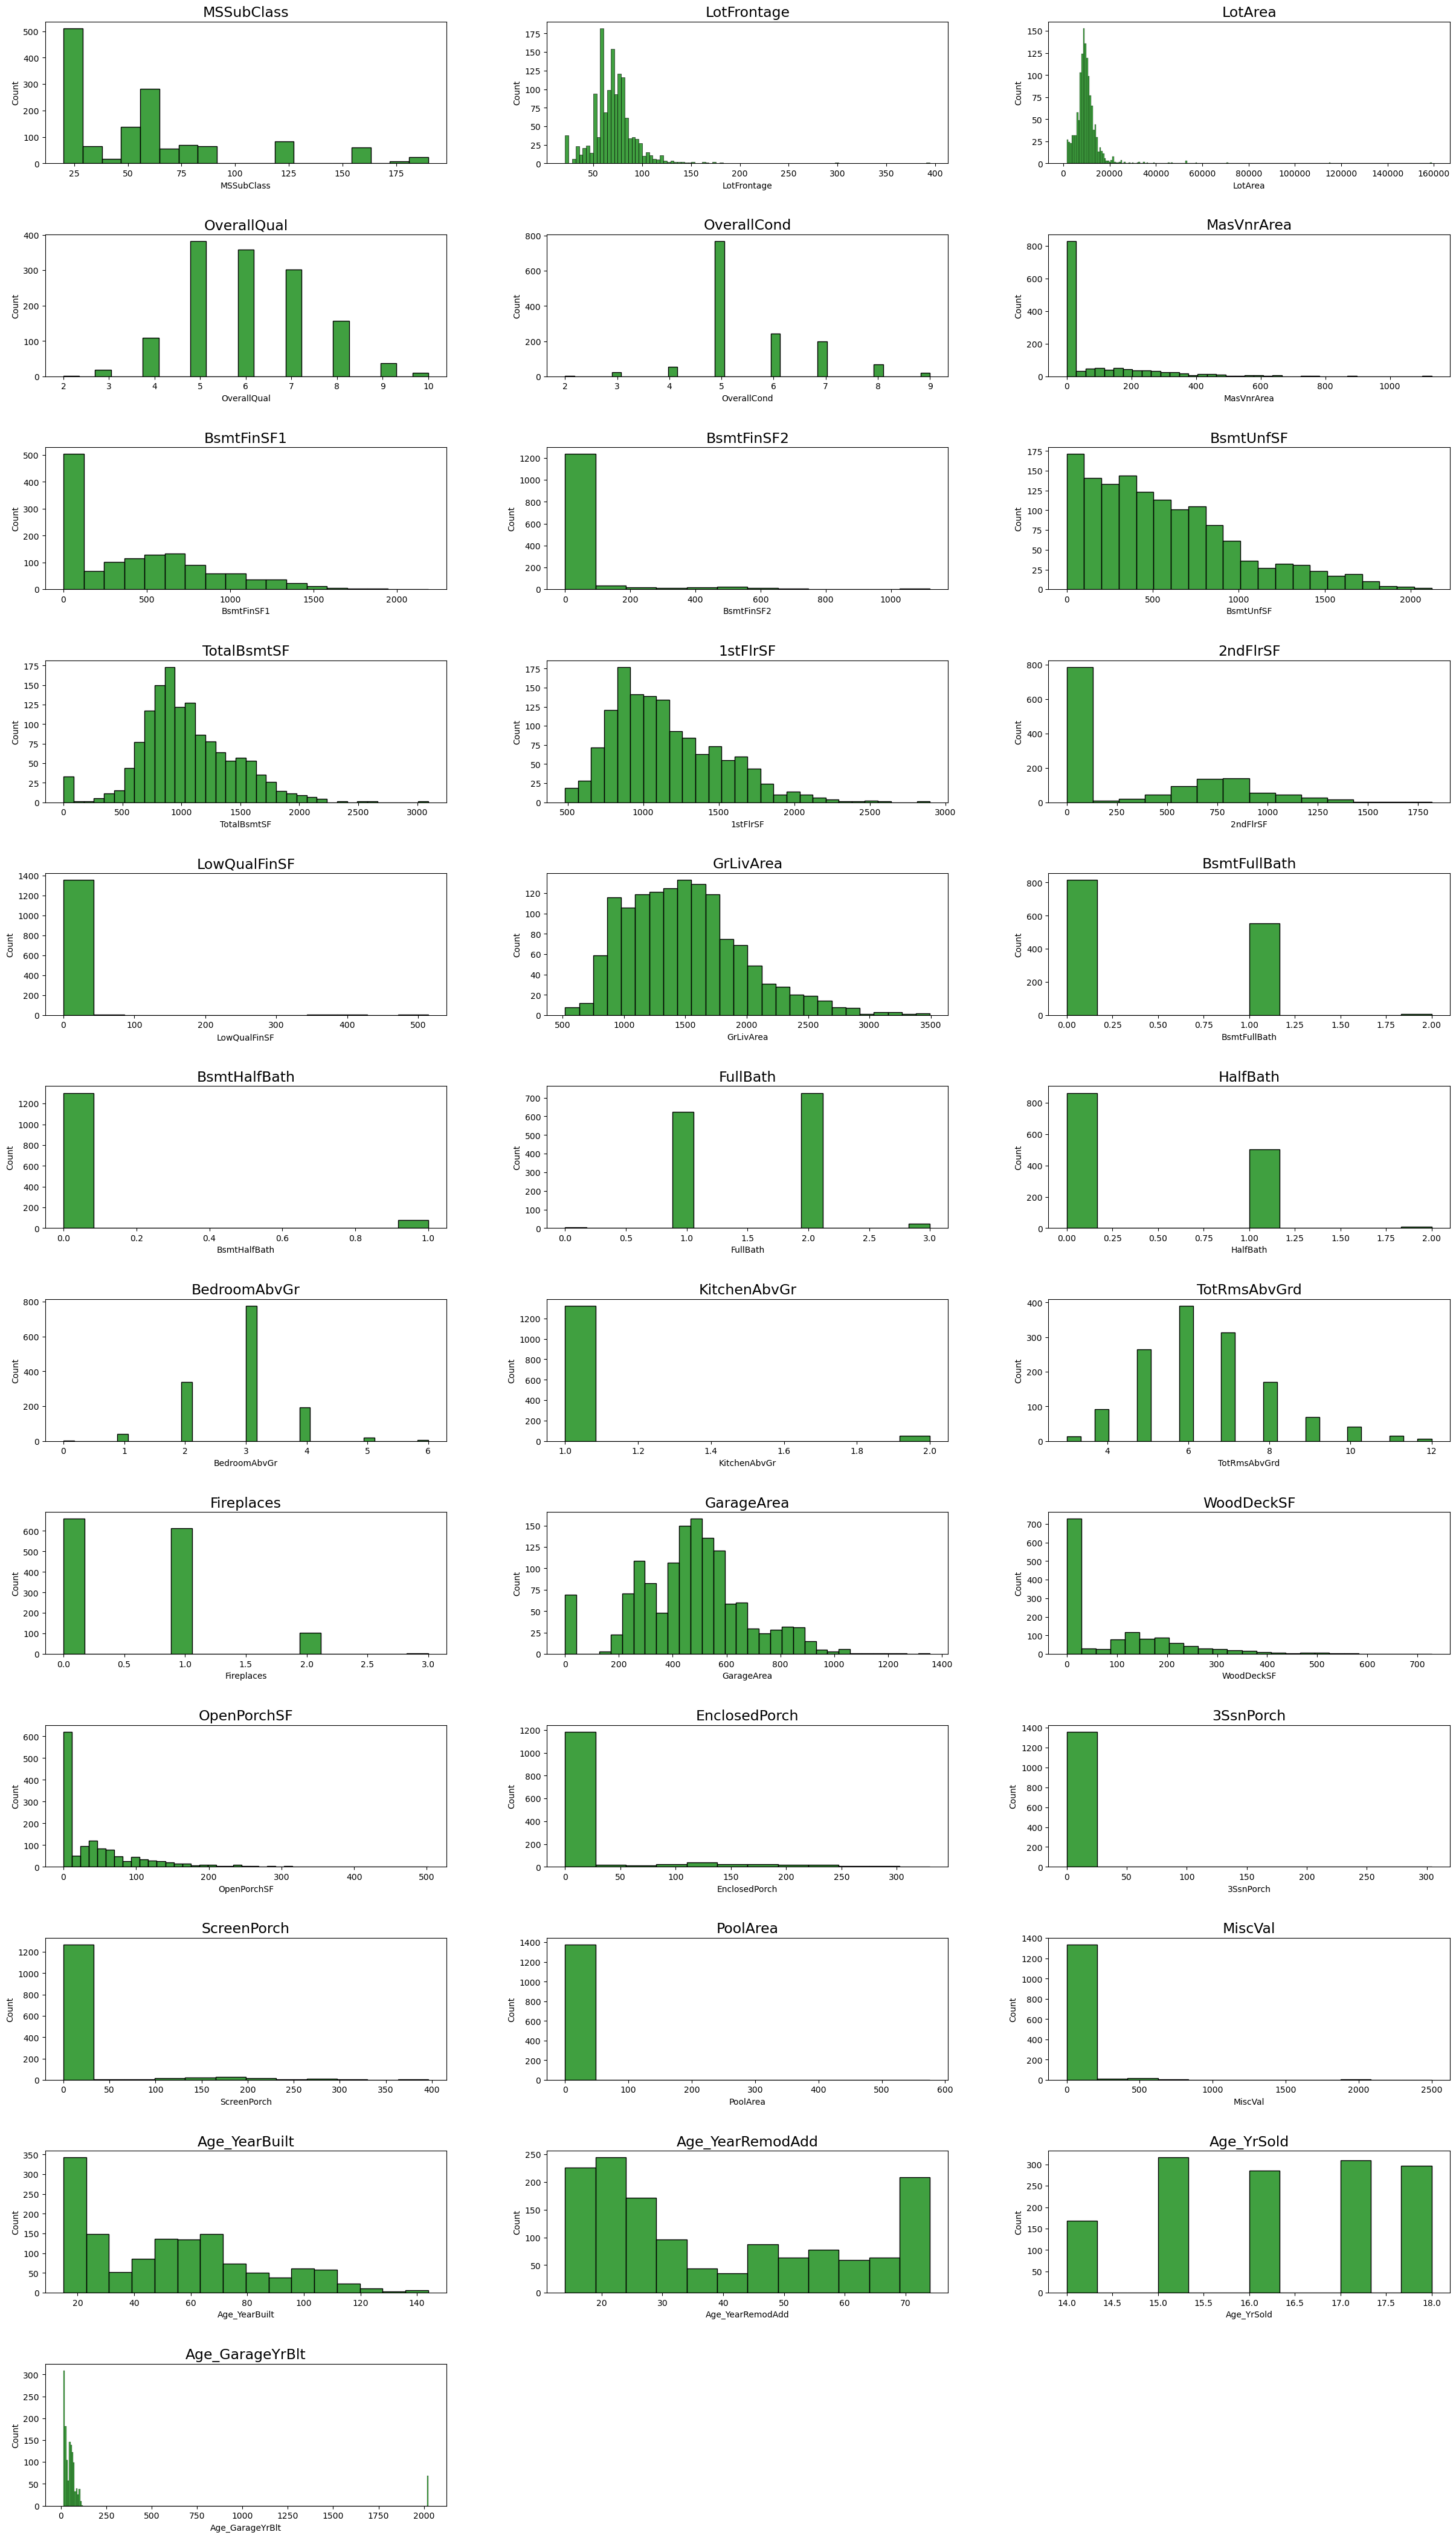

In [451]:
#data without categorized numerical columns
plt.figure(figsize=(30,90))
plt.subplots_adjust(hspace=0.5, wspace=0.25)
for n, col in enumerate(list(df_numerical_without)):
    plt.subplot(20,3,n+1)
    sns.histplot(df_numerical_without[col], color='green')
    plt.title(col, fontsize=17)
plt.show()

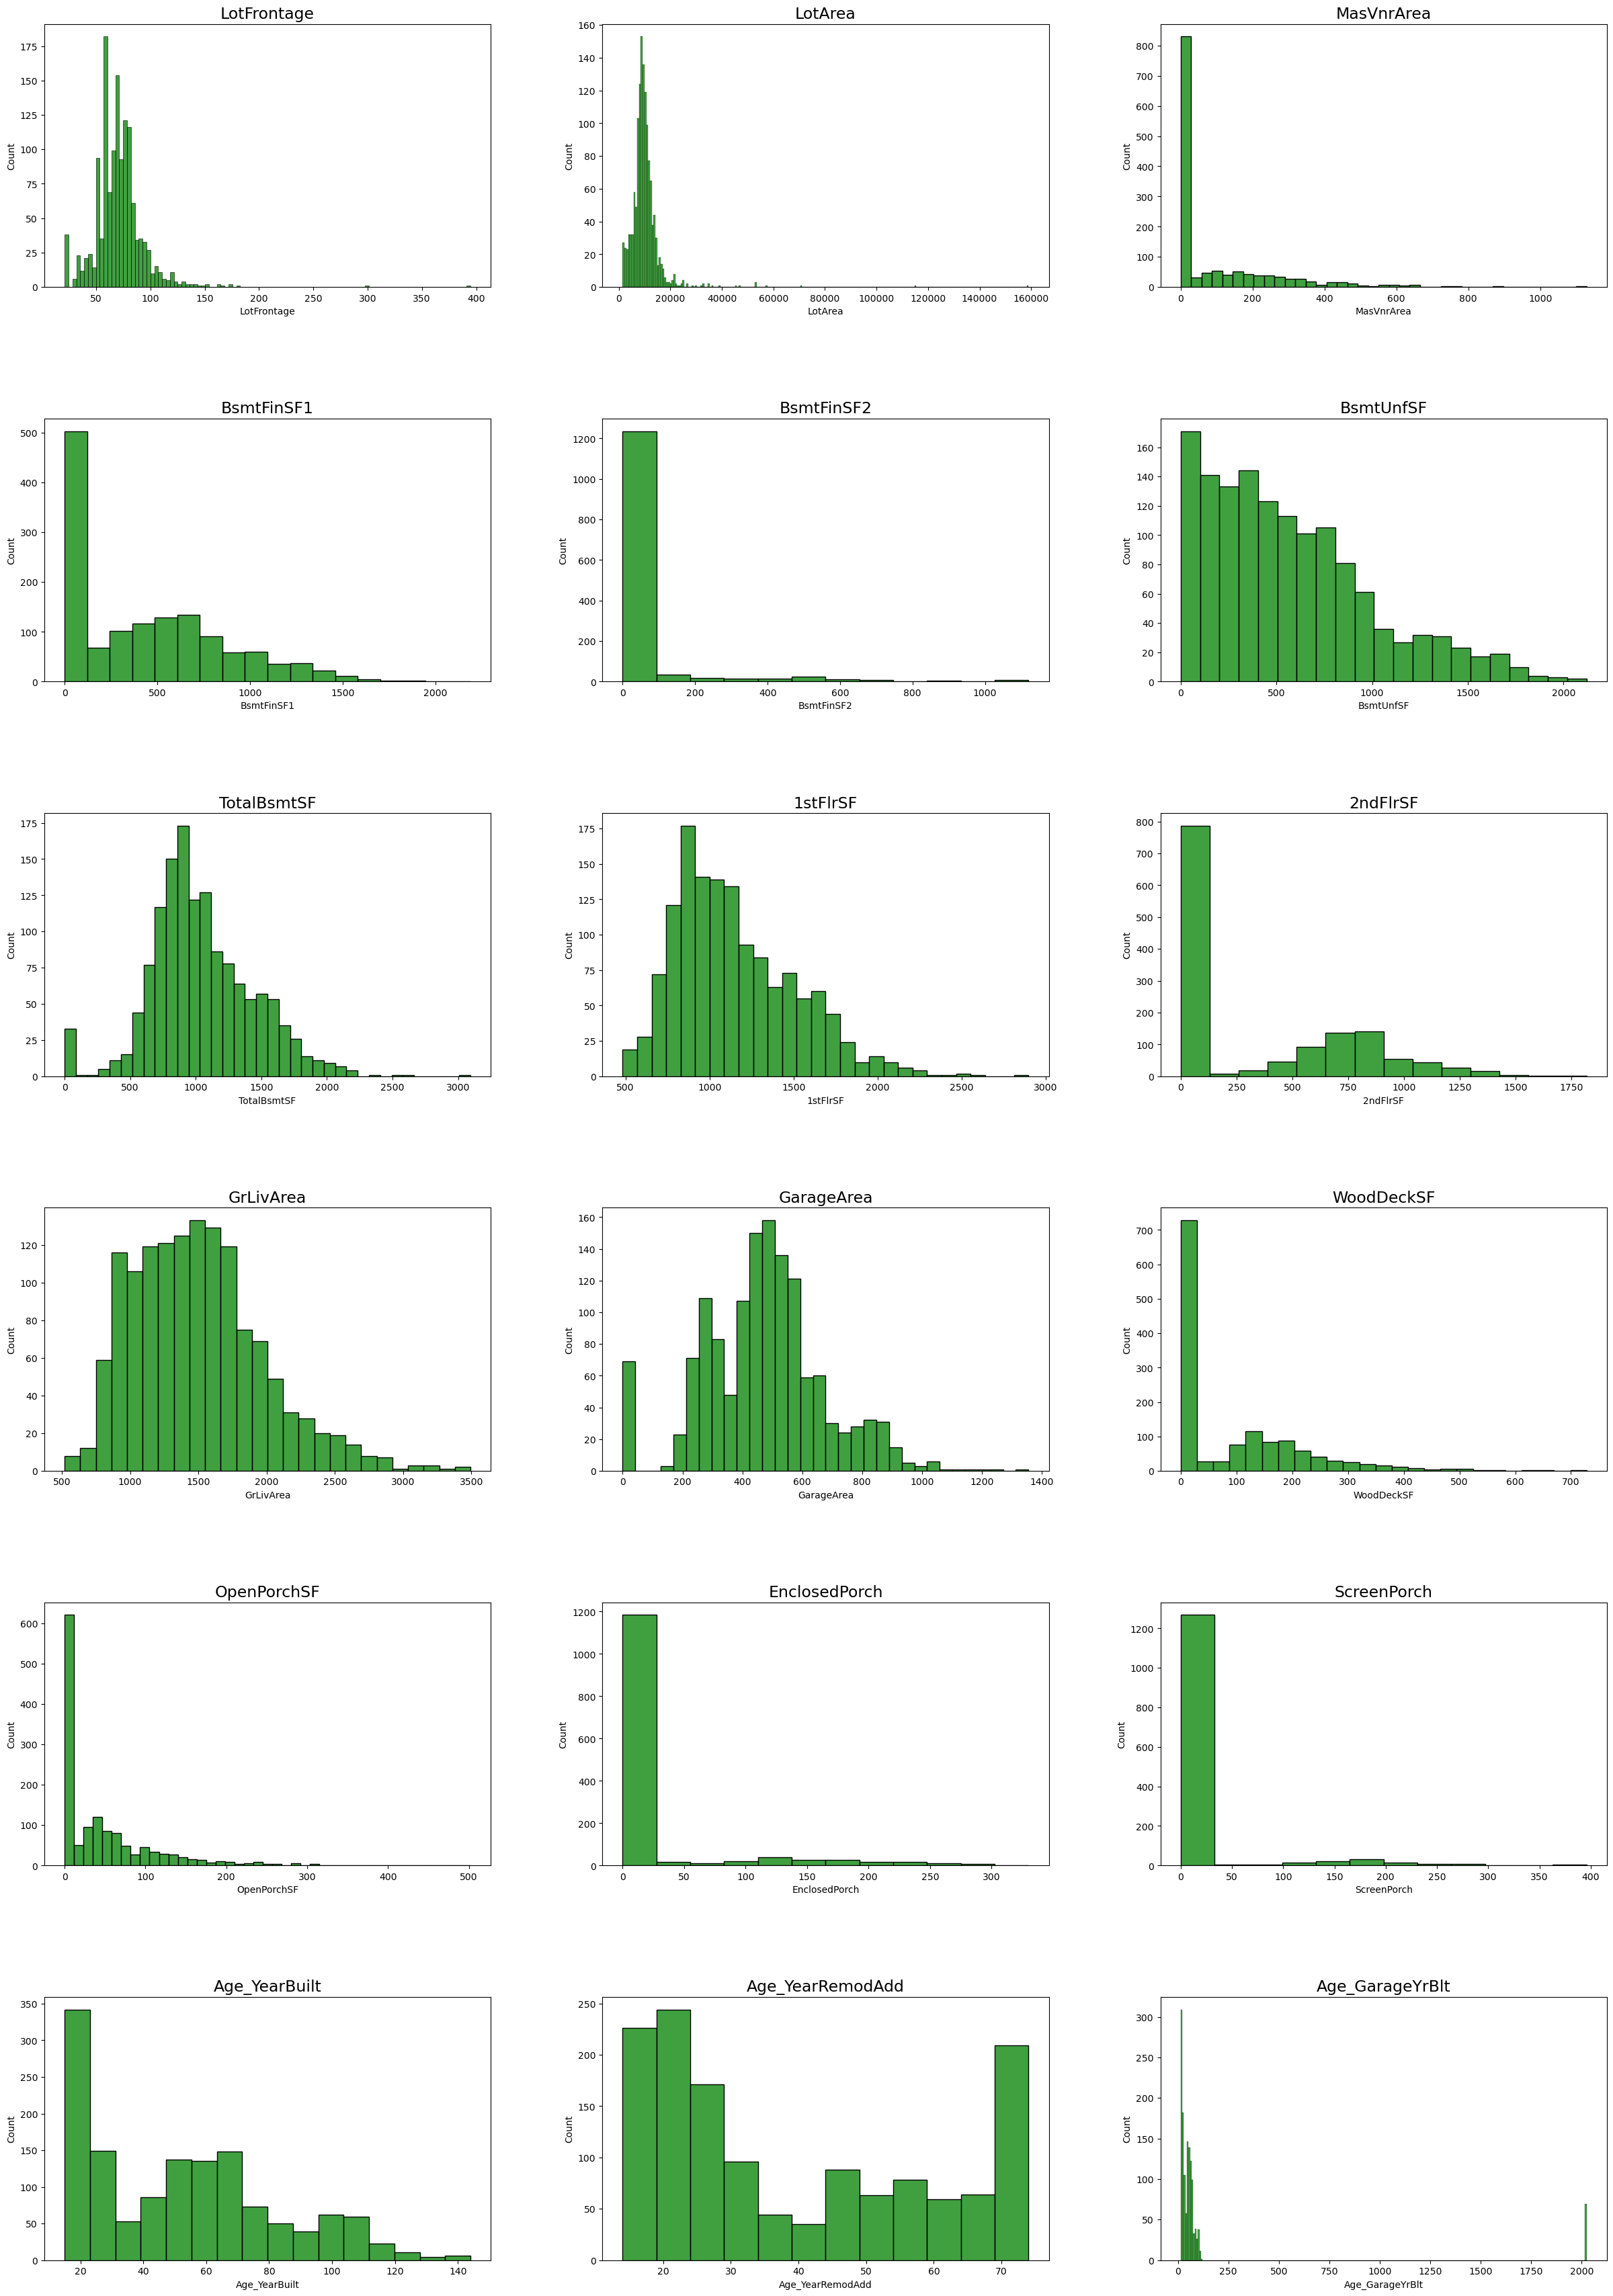

In [452]:
#data with categorized numerical columns
plt.figure(figsize=(30,150))
plt.subplots_adjust(hspace=0.5, wspace=0.25)
for n, col in enumerate(list(df_numerical_with)):
    plt.subplot(20,3,n+1)
    sns.histplot(df_numerical_with[col], color='green')
    plt.title(col, fontsize=17)
plt.show()

***WE ARE SELECTING NUMERICAL DATA WITH CATEGOIRIZED NUMCOLUMNS***

In [453]:
#logalize numerical data with categorized columns
def logalizer(df):
    nonzero = ['LotFrontage','LotArea','1stFlrSF','GrLivArea',
               'Age_YearBuilt','Age_YearRemodAdd','Age_GarageYrBlt']

    withzero = ['MasVnrArea','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','2ndFlrSF',
                'GarageArea' ,'WoodDeckSF','OpenPorchSF','EnclosedPorch','ScreenPorch']

    for i in nonzero:
        df['norm_'+i]=np.log(df[i])

    for i in withzero:
        
        df['Has_'+i] = pd.Series(len(df[i]),
                                   index=df.index)
        df['Has_'+i] = 0
        df.loc[df[i]>0, 'Has_'+i] = 1

        df.loc[df['Has_'+i]==1, i] = np.log(df[i])
        #df[i] = df[i].replace(0, np.nan)
    

    df[list(df.select_dtypes('int64'))]=df[list(df.select_dtypes('int64'))].astype('category')
    return df


df_numerical_with=logalizer(df_numerical_with)

In [454]:
#merge new data
df_with_logalized = pd.concat([df_numerical_with, df_categorical_with], axis=1)
df_with_logalized.head(2)

,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,...,PavedDrive,3SsnPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,SaleType,SaleCondition,Age_YrSold
0,71.002213,10382.0,5.480639,6.755769,3.465736,5.375278,7.009409,1107.0,6.890609,2090.0,...,Y,0.0,0.0,NoPool,NoFence,Shed,350.0,WD,Normal,15.0
1,70.000000,11200.0,0.000000,6.809039,0.000000,4.897840,6.946976,1040.0,0.000000,1040.0,...,Y,0.0,0.0,NoPool,NoFence,NoMiscFeature,0.0,WD,Normal,16.0


In [455]:
logalized_numerical = list(df_with_logalized.select_dtypes('number').columns)
df_with_logalized_numerical =df_with_logalized[logalized_numerical]
logalized_categorical = list(df_with_logalized.select_dtypes(['object','category']).columns)
df_with_logalized_categorical =df_with_logalized[logalized_categorical].astype('category')

In [456]:
#handle categorical data with dummies
def get_dummies(df_categorical_columns):
    for col in df_categorical_columns:
        get_dummy = pd.get_dummies(df_categorical_columns[col],drop_first=True ,prefix=col)
        df_categorical_columns = pd.concat([df_categorical_columns, get_dummy], axis=1)
    return df_categorical_columns

In [457]:
#get dummies
df_dummies_categorical_with = get_dummies(df_with_logalized_categorical)
df_dummies_categorical_with_final = df_dummies_categorical_with.drop(list(df_with_logalized_categorical.columns), axis=1)

In [458]:
#set right dtypes
def dtyper(df):
    numerical = df.select_dtypes(['int64','float64'])
    data_to_change = df.drop(list(numerical), axis=1)
    data_to_change = data_to_change.astype('bool')
    final_data = pd.concat([numerical,data_to_change], axis=1)
    return final_data

In [459]:
#not scaled
df_not_scaled = pd.concat([df_with_logalized_numerical, df_dummies_categorical_with_final, saleprice_to_join], axis=1)
df_not_scaled = dtyper(df_not_scaled)
df_not_scaled

,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,...,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Age_YrSold_15.0,Age_YrSold_16.0,Age_YrSold_17.0,Age_YrSold_18.0
0,71.002213,10382.0,5.480639,6.755769,3.465736,5.375278,7.009409,1107.0,6.890609,2090.0,...,True,False,False,False,True,False,True,False,False,False
1,70.000000,11200.0,0.000000,6.809039,0.000000,4.897840,6.946976,1040.0,0.000000,1040.0,...,True,False,False,False,True,False,False,True,False,False
2,76.634980,12968.0,0.000000,6.602588,0.000000,5.164786,6.815640,912.0,0.000000,912.0,...,True,False,False,False,True,False,False,True,False,False
3,72.174072,10920.0,5.356586,6.597146,0.000000,6.253829,7.133296,1253.0,0.000000,1253.0,...,True,False,False,False,True,False,False,True,False,False
4,51.000000,6120.0,0.000000,0.000000,0.000000,6.723832,6.723832,854.0,0.000000,854.0,...,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1372,62.000000,7500.0,0.000000,6.016157,0.000000,6.698268,7.107425,1221.0,0.000000,1221.0,...,True,False,False,False,True,False,True,False,False,False
1373,62.000000,7917.0,0.000000,0.000000,0.000000,6.859615,6.859615,953.0,6.542472,1647.0,...,True,False,False,False,True,False,False,False,True,False
1374,85.000000,13175.0,4.779123,6.672033,5.093750,6.378426,7.340836,2073.0,0.000000,2073.0,...,True,False,False,False,True,False,False,False,False,False
1375,66.000000,9042.0,0.000000,5.616771,0.000000,6.776507,7.049255,1188.0,7.049255,2340.0,...,True,False,False,False,True,False,False,False,False,False


In [460]:
#standardscaler
std_scl = StandardScaler()
numerical_scaled = std_scl.fit_transform(df_with_logalized_numerical)
df_numerical_scaled = pd.DataFrame(numerical_scaled, columns=df_with_logalized_numerical.columns)
df_numerical_scaled

,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,...,Age_YearBuilt,Age_YearRemodAdd,Age_GarageYrBlt,norm_LotFrontage,norm_LotArea,norm_1stFlrSF,norm_GrLivArea,norm_Age_YearBuilt,norm_Age_YearRemodAdd,norm_Age_GarageYrBlt
0,0.021123,0.031308,1.279200,0.853644,1.557421,-0.160451,0.232121,-0.124560,1.234818,1.246546,...,-0.051401,0.569255,-0.216729,0.175211,0.296212,0.023130,1.212511,0.239975,0.753048,0.067065
1,-0.021915,0.144717,-0.814028,0.871474,-0.350767,-0.422049,0.176018,-0.310921,-0.864994,-0.950774,...,0.217593,0.955943,-0.198223,0.131554,0.449937,-0.181509,-0.982271,0.475482,1.023400,0.209497
2,0.263011,0.389835,-0.814028,0.802373,-0.350767,-0.275784,0.057998,-0.666954,-0.864994,-1.218638,...,0.318465,1.100951,-0.191283,0.409662,0.747032,-0.611993,-1.395276,0.555644,1.115422,0.257978
3,0.071446,0.105897,1.231821,0.800551,-0.350767,0.320924,0.343448,0.281540,-0.864994,-0.505032,...,0.385714,1.197623,-0.186657,0.225484,0.398619,0.429198,-0.396362,0.606958,1.174328,0.289012
4,-0.837834,-0.559582,-0.814028,-1.407570,-0.350767,0.578448,-0.024501,-0.828282,-0.864994,-1.340013,...,1.428063,-0.784152,-0.258367,-0.840951,-0.775063,-0.827368,-1.601907,1.245369,-0.724460,-0.358455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1372,-0.365460,-0.368257,-0.814028,0.606090,-0.350767,0.564441,0.320200,0.192532,-0.864994,-0.571998,...,-1.093750,-0.977496,-0.288439,-0.241150,-0.362898,0.344401,-0.477715,-1.272992,-1.078943,-0.847960
1373,-0.365460,-0.310443,-0.814028,-1.407570,-0.350767,0.652846,0.097514,-0.552912,1.128729,0.319486,...,-0.925629,-0.735816,-0.276873,-0.241150,-0.253220,-0.467855,0.463430,-0.912335,-0.645495,-0.629839
1374,0.622230,0.418533,1.011270,0.825617,2.453784,0.389193,0.529945,2.562378,-0.864994,1.210970,...,-0.219522,-0.155784,-0.228295,0.727815,0.779132,2.079391,1.186828,0.073203,0.106802,-0.033797
1375,-0.193688,-0.154472,-0.814028,0.472412,-0.350767,0.607309,0.267927,0.100742,1.283163,1.769717,...,1.024573,-1.025832,-0.142706,-0.049148,0.016099,0.254595,1.567815,1.027116,-1.179259,0.543119


In [461]:
#almost final dataframe scaled
df_almost_final = pd.concat([df_numerical_scaled, df_dummies_categorical_with_final, saleprice_to_join], axis=1)
df_almost_final = dtyper(df_almost_final)
df_almost_final

,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,...,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Age_YrSold_15.0,Age_YrSold_16.0,Age_YrSold_17.0,Age_YrSold_18.0
0,0.021123,0.031308,1.279200,0.853644,1.557421,-0.160451,0.232121,-0.124560,1.234818,1.246546,...,True,False,False,False,True,False,True,False,False,False
1,-0.021915,0.144717,-0.814028,0.871474,-0.350767,-0.422049,0.176018,-0.310921,-0.864994,-0.950774,...,True,False,False,False,True,False,False,True,False,False
2,0.263011,0.389835,-0.814028,0.802373,-0.350767,-0.275784,0.057998,-0.666954,-0.864994,-1.218638,...,True,False,False,False,True,False,False,True,False,False
3,0.071446,0.105897,1.231821,0.800551,-0.350767,0.320924,0.343448,0.281540,-0.864994,-0.505032,...,True,False,False,False,True,False,False,True,False,False
4,-0.837834,-0.559582,-0.814028,-1.407570,-0.350767,0.578448,-0.024501,-0.828282,-0.864994,-1.340013,...,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1372,-0.365460,-0.368257,-0.814028,0.606090,-0.350767,0.564441,0.320200,0.192532,-0.864994,-0.571998,...,True,False,False,False,True,False,True,False,False,False
1373,-0.365460,-0.310443,-0.814028,-1.407570,-0.350767,0.652846,0.097514,-0.552912,1.128729,0.319486,...,True,False,False,False,True,False,False,False,True,False
1374,0.622230,0.418533,1.011270,0.825617,2.453784,0.389193,0.529945,2.562378,-0.864994,1.210970,...,True,False,False,False,True,False,False,False,False,False
1375,-0.193688,-0.154472,-0.814028,0.472412,-0.350767,0.607309,0.267927,0.100742,1.283163,1.769717,...,True,False,False,False,True,False,False,False,False,False


In [462]:
#normalized dataframe
df_to_normalize = pd.concat([df_with_logalized_numerical, df_dummies_categorical_with_final],axis=1)
df_to_normalize = dtyper(df_to_normalize)
df_to_normalize

,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,...,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Age_YrSold_15.0,Age_YrSold_16.0,Age_YrSold_17.0,Age_YrSold_18.0
0,71.002213,10382.0,5.480639,6.755769,3.465736,5.375278,7.009409,1107.0,6.890609,2090.0,...,True,False,False,False,True,False,True,False,False,False
1,70.000000,11200.0,0.000000,6.809039,0.000000,4.897840,6.946976,1040.0,0.000000,1040.0,...,True,False,False,False,True,False,False,True,False,False
2,76.634980,12968.0,0.000000,6.602588,0.000000,5.164786,6.815640,912.0,0.000000,912.0,...,True,False,False,False,True,False,False,True,False,False
3,72.174072,10920.0,5.356586,6.597146,0.000000,6.253829,7.133296,1253.0,0.000000,1253.0,...,True,False,False,False,True,False,False,True,False,False
4,51.000000,6120.0,0.000000,0.000000,0.000000,6.723832,6.723832,854.0,0.000000,854.0,...,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1372,62.000000,7500.0,0.000000,6.016157,0.000000,6.698268,7.107425,1221.0,0.000000,1221.0,...,True,False,False,False,True,False,True,False,False,False
1373,62.000000,7917.0,0.000000,0.000000,0.000000,6.859615,6.859615,953.0,6.542472,1647.0,...,True,False,False,False,True,False,False,False,True,False
1374,85.000000,13175.0,4.779123,6.672033,5.093750,6.378426,7.340836,2073.0,0.000000,2073.0,...,True,False,False,False,True,False,False,False,False,False
1375,66.000000,9042.0,0.000000,5.616771,0.000000,6.776507,7.049255,1188.0,7.049255,2340.0,...,True,False,False,False,True,False,False,False,False,False


In [463]:
def my_normalizer(df):
    norm = Normalizer()
    numerical = df.select_dtypes('number')
    categorical = df.drop(list(numerical), axis=1)
    transformed_numerical = norm.fit_transform(numerical)
    df_transformed_numerical = pd.DataFrame(transformed_numerical, columns=list(numerical))
    final_df = pd.concat([df_transformed_numerical,categorical], axis=1)
    return final_df

In [464]:
df_normalized = my_normalizer(df_to_normalize)
df_normalized = df_normalized.join(saleprice_to_join)
df_normalized

,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,...,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Age_YrSold_15.0,Age_YrSold_16.0,Age_YrSold_17.0,Age_YrSold_18.0,SalePrice
0,0.006668,0.974963,0.000515,0.000634,0.000325,0.000505,0.000658,0.103957,0.000647,0.196270,...,False,False,False,True,False,True,False,False,False,200000.0
1,0.006196,0.991426,0.000000,0.000603,0.000000,0.000434,0.000615,0.092061,0.000000,0.092061,...,False,False,False,True,False,False,True,False,False,129500.0
2,0.005880,0.995038,0.000000,0.000507,0.000000,0.000396,0.000523,0.069978,0.000000,0.069978,...,False,False,False,True,False,False,True,False,False,144000.0
3,0.006524,0.987016,0.000484,0.000596,0.000000,0.000565,0.000645,0.113254,0.000000,0.113254,...,False,False,False,True,False,False,True,False,False,157000.0
4,0.008174,0.980907,0.000000,0.000000,0.000000,0.001078,0.001078,0.136878,0.000000,0.136878,...,False,False,False,True,False,False,False,True,False,132000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1372,0.008056,0.974461,0.000000,0.000782,0.000000,0.000870,0.000923,0.158642,0.000000,0.158642,...,False,False,False,True,False,True,False,False,False,185000.0
1373,0.007614,0.972266,0.000000,0.000000,0.000000,0.000842,0.000842,0.117035,0.000803,0.202264,...,False,False,False,True,False,False,False,True,False,175000.0
1374,0.006297,0.976090,0.000354,0.000494,0.000377,0.000473,0.000544,0.153581,0.000000,0.153581,...,False,False,False,True,False,False,False,False,False,210000.0
1375,0.007009,0.960266,0.000000,0.000597,0.000000,0.000720,0.000749,0.126166,0.000749,0.248510,...,False,False,False,True,False,False,False,False,False,266500.0


# Training Models

In [465]:
trained_data_not_scaled = df_not_scaled.copy()
trained_data_scaled = df_almost_final.copy()
trained_data_normalized = df_normalized.copy()

In [466]:
#models to train
lin_reg = LinearRegression()
knn_reg = KNeighborsRegressor()
tree_reg = DecisionTreeRegressor()
forest_reg = RandomForestRegressor()
sgd_reg = SGDRegressor()
ridge_reg = Ridge()
lasso_reg = Lasso()
elasticnet_reg = ElasticNet()
log_reg = LogisticRegression()
linSVR_reg = LinearSVR()
gbr_reg = GradientBoostingRegressor()
xgb_reg = XGBRegressor()
lgbm_reg = LGBMRegressor(verbosity=-1)

models_list = {'Linear_Regression':lin_reg,
               'KNeighbors_Regression':knn_reg,
               'Decision_Tree':tree_reg, 
               'Random_Forest':forest_reg, 
               'SGD_Regression':sgd_reg, 
               'Ridge_Regression':ridge_reg,
               'Lasso_Regression':lasso_reg, 
               'ElasticNet_Regression':elasticnet_reg, 
               'Logistic_Regression':log_reg, 
               'LinearSVR':linSVR_reg,
               'GradientBoosting_Regression':gbr_reg, 
               'XGBoost_Regression':xgb_reg, 
               'LightGBM_Regression':lgbm_reg}

In [467]:
#train basic models
def basic_models(df_results,datasetname ,models, cv_method, features_train, target_train):
    from sklearn.metrics import mean_squared_error
    from sklearn.model_selection import cross_val_score
    
    scoring = 'neg_mean_squared_error'
    cv = 10
    df_final = df_results.copy()
    for key, model in models.items():
        
        if cv_method == 'cross_val_score':
            train_X, test_X, train_y, test_y = train_test_split(features_train, target_train,test_size=0.1 ,random_state=1)
            tm = model.fit(train_X, train_y)
            tm_predict = tm.predict(test_X)
            prediction = np.sqrt(mean_squared_error(test_y, tm_predict))
            
            model_cv = cross_val_score(model, train_X, train_y,
                                       scoring=scoring, cv=cv)
            score = np.sqrt(-model_cv)
            df_created = pd.DataFrame(
            {'datasetname': datasetname,
             'model': key,
             'cv_method': cv_method,
             'basic_prediction_mean': [prediction],
             'rmse_mean': score.mean(),
             'rmse_std': score.std(),
             'parameters': 'None'})
            
            df_full_results = pd.concat([df_results,df_created], axis=0, ignore_index=True)
            
        if cv_method == 'kfold':
            predictions = []
            rmse = []
            kf = KFold(n_splits=10,shuffle=True ,random_state=12)
            for train_index, test_index in kf.split(features_train):
                train_X, test_X = features_train.iloc[train_index], features_train.iloc[test_index]
                train_y, test_y = target_train.iloc[train_index], target_train.iloc[test_index]
                
                tm = model.fit(train_X, train_y)
                tm_predict = tm.predict(test_X)
                prediction = np.sqrt(mean_squared_error(test_y, tm_predict))
                rmse.append(prediction)
                predictions.append(prediction)
                
                df_created = pd.DataFrame(
                {'datasetname': datasetname,
                 'model': key,
                 'cv_method': cv_method,
                 'basic_prediction_mean': [np.min(predictions)],
                 'rmse_mean': np.mean(rmse),
                 'rmse_std': np.std(rmse),
                 'parameters': 'None'})

                df_full_results = pd.concat([df_results,df_created], axis=0, ignore_index=True)
            
        if cv_method == 'repeatedkfold':
            predictions = []
            rmse = []
            rkf = RepeatedKFold(n_splits=10, random_state=12)
            for train_index, test_index in rkf.split(features_train):
                train_X, test_X = features_train.iloc[train_index], features_train.iloc[test_index]
                train_y, test_y = target_train.iloc[train_index], target_train.iloc[test_index]
                
                tm = model.fit(train_X, train_y)
                tm_predict = tm.predict(test_X)
                prediction = np.sqrt(mean_squared_error(test_y, tm_predict))
                rmse.append(prediction)
                predictions.append(prediction)
                
                df_created = pd.DataFrame(
                {'datasetname': datasetname,
                 'model': key,
                 'cv_method': cv_method,
                 'basic_prediction_mean': [np.min(predictions)],
                 'rmse_mean': np.mean(rmse),
                 'rmse_std': np.std(rmse),
                 'parameters': 'None'})

                df_full_results = pd.concat([df_results,df_created], axis=0, ignore_index=True)
        
        if cv_method == 'stratifiedkfold':
            predictions = []
            rmse = []
            skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=12)
            for train_index, test_index in skf.split(features_train, target_train):
                train_X, test_X = features_train.iloc[train_index], features_train.iloc[test_index]
                train_y, test_y = target_train.iloc[train_index], target_train.iloc[test_index]
                
                tm = model.fit(train_X, train_y)
                tm_predict = tm.predict(test_X)
                prediction = np.sqrt(mean_squared_error(test_y, tm_predict))
                rmse.append(prediction)
                predictions.append(prediction)
                
                df_created = pd.DataFrame(
                {'datasetname': datasetname,
                 'model': key,
                 'cv_method': cv_method,
                 'basic_prediction_mean': [np.min(predictions)],
                 'rmse_mean': np.mean(rmse),
                 'rmse_std': np.std(rmse),
                 'parameters': 'None'})

                df_full_results = pd.concat([df_results,df_created], axis=0, ignore_index=True)
        
        if cv_method == 'shufflesplit':
            predictions = []
            rmse = []
            shs = ShuffleSplit(n_splits=10, test_size=0.25, random_state=12)
            for train_index, test_index in shs.split(features_train):
                train_X, test_X = features_train.iloc[train_index], features_train.iloc[test_index]
                train_y, test_y = target_train.iloc[train_index], target_train.iloc[test_index]
                
                tm = model.fit(train_X, train_y)
                tm_predict = tm.predict(test_X)
                prediction = np.sqrt(mean_squared_error(test_y, tm_predict))
                rmse.append(prediction)
                predictions.append(prediction)
                
                df_created = pd.DataFrame(
                {'datasetname': datasetname,
                 'model': key,
                 'cv_method': cv_method,
                 'basic_prediction_mean': [np.min(predictions)],
                 'rmse_mean': np.mean(rmse),
                 'rmse_std': np.std(rmse),
                 'parameters': 'None'})

                df_full_results = pd.concat([df_results,df_created], axis=0, ignore_index=True)
        
        
        
        df_row = pd.DataFrame(
            {'datasetname': [df_full_results.loc[0]['datasetname']] ,
             'model': [df_full_results.loc[0]['model']] ,
             'cv_method': [df_full_results.loc[0]['cv_method']],
             'basic_prediction_mean': [df_full_results['basic_prediction_mean'].mean()],
             'rmse_mean': [df_full_results.loc[0]['rmse_mean']],
             'rmse_std': [df_full_results.loc[0]['rmse_std']],
             'parameters': 'None'})
        
        
        df_final = pd.concat([df_final,df_row], axis=0, ignore_index=True)
    return df_final

In [468]:
#dataframe for holding training results
df_results = pd.DataFrame(columns=['datasetname',
                                   'model',
                                   'cv_method',
                                   'basic_prediction_mean',
                                   'rmse_mean',
                                   'rmse_std',
                                   'parameters'])

In [469]:
#evaluation methods
eval_methods = ['cross_val_score',
                'kfold',
                'repeatedkfold',
                'stratifiedkfold',
                'shufflesplit']

In [470]:
#models trainer
def train_models(df_results, dataframes_dict, eval_methods, models_list):

    final_result = []

    for key,value in dataframes_dict.items():
        features_train = value.drop('SalePrice', axis=1)
        target_train = value['SalePrice']
        print(f'training data: {key}')
        for method in eval_methods:
            print(f'training method: {method}')
            result = basic_models(df_results,key, models_list, method, features_train, target_train)
            final_result.append(result)
            print('done method')
        print('done data')

    final_data_of_trained_models = pd.concat(final_result, axis=0)
    return final_data_of_trained_models

In [471]:
#dataframes dict
dataframes_dict = {'df_logalized_scaled':trained_data_scaled,
                   'df_logalized_not_scaled':trained_data_not_scaled,
                   'df_normalized': trained_data_normalized}

***Train models without params***

In [472]:
#train models

#df_models_trained_no_params = train_models(df_results,dataframes_dict,eval_methods,models_list)
#df_models_trained_no_params.to_csv('./v2_trained_models_df.csv')

In [473]:
# df_models_trained_no_params2 = pd.read_csv('./v2_trained_models_df2.csv', index_col=0)
# df_models_trained_no_params2.sort_values(by='rmse_mean').head(20)

In [474]:
df_models_trained_no_params = pd.read_csv('./v2_trained_models_df.csv', index_col=0)
df_models_trained_no_params.sort_values(by='rmse_mean').head(20)

,datasetname,model,cv_method,basic_prediction_mean,rmse_mean,rmse_std,parameters
17,df_normalized_scaled,SGD_Regression,kfold,16380.967550,20363.476881,2429.741564,None
30,df_normalized_scaled,SGD_Regression,repeatedkfold,14168.237894,20410.467188,2671.411761,None
43,df_normalized_scaled,SGD_Regression,stratifiedkfold,16287.699134,20447.828188,3245.479007,None
18,df_normalized_scaled,Ridge_Regression,kfold,16581.699674,20764.158638,2823.131327,None
83,df_normalized_not_scaled,Ridge_Regression,kfold,16734.067681,20781.207739,2822.380310,None
56,df_normalized_scaled,SGD_Regression,shufflesplit,18510.146083,20887.967313,1416.895851,None
4,df_normalized_scaled,SGD_Regression,cross_val_score,19857.144404,20925.362670,3459.180238,None
31,df_normalized_scaled,Ridge_Regression,repeatedkfold,15413.359868,20962.359951,2519.764917,None
96,df_normalized_not_scaled,Ridge_Regression,repeatedkfold,15292.775038,20972.332410,2536.869516,None
44,df_normalized_scaled,Ridge_Regression,stratifiedkfold,16358.752937,21067.834942,3261.573040,None


***Train models with params***

In [475]:
final_models_list = {'SGD_Regression':sgd_reg,
                     'Ridge_Regression':ridge_reg,
                     'GradientBoosting_Regression':gbr_reg, 
                     'LightGBM_Regression':lgbm_reg}

In [476]:
final_models_with_params_search = {

'SGD_Regression':{'loss':['squared_error', 'huber', 'epsilon_insensitive','squared_epsilon_insensitive'],
                  'penalty':['l2','l1'],
                  'alpha':[0.0001,0.0002,0.0003,0.0004,0.0005],
                  'l1_ratio':[0.01,0.05,0.10,0.15,0.20,0.25],
                  'fit_intercept':[True, False],
                  'max_iter':[1000,1500,2000],
                  'tol':[0.0001,0.001,0.002,0.003,0.004,0.005],
                  'shuffle':[True, False],
                  'epsilon':[0.01,0.05,0.1,0.2,0.3,0.4,0.5],
                  'learning_rate':['constant','optimal','invscaling','adaptive'],
                  'eta0':[0.001,0.005,0.01,0.02,0.03,0.04,0.05],
                  'power_t':[0.05,0.10,0.15,0.20,0.25,0.40,0.50],
                  'early_stopping':[True, False],
                  'n_iter_no_change':[4,5,6,7,8,9,10]},
    
'Ridge_Regression':{'alpha':[1,2,3,4,5,6,7,10],
                    'fit_intercept':[True, False],
                    'solver':['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs']},

'GradientBoosting_Regression':{'loss':['squared_error', 'absolute_error', 'huber', 'quantile'],
                               'learning_rate':[0.05,0.1,0.2,0.3],
                               'n_estimators':[100,200,300,400,500],
                               'criterion':['friedman_mse','squared_error'],
                               'min_samples_split':[2,3,4,5],
                               'min_samples_leaf':[1,2,3,4,5],
                               'max_depth':[1,2,3,4,5,6],
                               'validation_fraction':[0.1,0.2,0.3],
                               'max_features':['sqrt','log2', None]}, 
    
'LightGBM_Regression':{'boosting':['gbdt','gbrt','dart', 'rf'],
                       'data_sample_strategy':['bagging','goss'],
                       'num_iterations':[100,200,300,400,500]}
}

***RandomizedSearch for parameters***

In [477]:
# my_dict = dict()
# for name,value in dataframes_dict.items():
#     features_train = value.drop('SalePrice', axis=1)
#     target_train = value['SalePrice']
#     print(f'training data: {name}')
#     for key,model in final_models_list.items():
#         gridsearch = RandomizedSearchCV(model,final_models_with_params_search[key], cv=5,scoring='neg_mean_squared_error',verbose=0)
#         best_model = gridsearch.fit(features_train, target_train)
#         print(f'{key}:{best_model.best_estimator_}')
#         my_dict[key]=(name, best_model.best_estimator_)
# my_dict

In [478]:
# training data: df_logalized_scaled

# SGD_Regression:SGDRegressor(alpha=0.0003, epsilon=0.5, eta0=0.005, fit_intercept=False,
#              l1_ratio=0.1, learning_rate='adaptive',
#              loss='squared_epsilon_insensitive', max_iter=2000, penalty='l1',
#              power_t=0.4)

# Ridge_Regression:Ridge(alpha=6)

# GradientBoosting_Regression:GradientBoostingRegressor(criterion='squared_error', max_depth=5,
#                           max_features='sqrt', min_samples_leaf=2,
#                           min_samples_split=5, n_estimators=300)
    
# LightGBM_Regression:LGBMRegressor(boosting='dart', data_sample_strategy='bagging',
#               num_iterations=500, verbosity=-1)

In [479]:
#prepare final models with params for training data: df_logalized_scaled
sgd_reg_params_ns = SGDRegressor(alpha=0.0003, epsilon=0.5, eta0=0.005, fit_intercept=False,
             l1_ratio=0.1, learning_rate='adaptive',
             loss='squared_epsilon_insensitive', max_iter=2000, penalty='l1',
             power_t=0.4)

ridge_reg_params_ns = Ridge(alpha=6)

gbr_reg_params_ns = GradientBoostingRegressor(criterion='squared_error', max_depth=5,
                          max_features='sqrt', min_samples_leaf=2,
                          min_samples_split=5, n_estimators=300)

lgbm_reg_params_ns = LGBMRegressor(boosting='dart', data_sample_strategy='bagging',
              num_iterations=500, verbosity=-1)

vot_reg_ns = VotingRegressor([('sgd',sgd_reg_params_ns),
                           ('ridge', ridge_reg_params_ns),
                           ('gbr', gbr_reg_params_ns),
                           ('lgbm', lgbm_reg_params_ns)]
                            )


final_models_list_with_params_ns = {'SGD_Regression':sgd_reg_params_ns, 
                                 'Ridge_Regression':ridge_reg_params_ns,
                                 'GBR_Regression':gbr_reg_params_ns, 
                                 'LightGBM_Regression':lgbm_reg_params_ns,
                                 'Voting_Regressor':vot_reg_ns
                                }

In [480]:
# training data: df_normalized_not_scaled

# SGD_Regression:SGDRegressor(alpha=0.0003, epsilon=0.05, eta0=0.005, fit_intercept=False,
#              l1_ratio=0.1, loss='huber', n_iter_no_change=8, penalty='l1',
#              power_t=0.2, shuffle=False, tol=0.004)

# Ridge_Regression:Ridge(alpha=5, fit_intercept=False)

# GradientBoosting_Regression:GradientBoostingRegressor(loss='huber', max_depth=5, max_features='sqrt',
#                           min_samples_leaf=4, min_samples_split=5,
#                           n_estimators=500, validation_fraction=0.3)
    
# LightGBM_Regression:LGBMRegressor(boosting='gbrt', data_sample_strategy='bagging',
#               num_iterations=400, verbosity=-1)

In [481]:
#prepare final models with params for training data: df_normalized_not_scaled
sgd_reg_params_nns = SGDRegressor(alpha=0.0003, epsilon=0.05, eta0=0.005, fit_intercept=False,
             l1_ratio=0.1, loss='huber', n_iter_no_change=8, penalty='l1',
             power_t=0.2, shuffle=False, tol=0.004)

ridge_reg_params_nns = Ridge(alpha=5, fit_intercept=False)

gbr_reg_params_nns = GradientBoostingRegressor(loss='huber', max_depth=5, max_features='sqrt',
                          min_samples_leaf=4, min_samples_split=5,
                          n_estimators=500, validation_fraction=0.3)

lgbm_reg_params_nns = LGBMRegressor(boosting='gbrt', data_sample_strategy='bagging',
              num_iterations=400, verbosity=-1)

vot_reg_nns = VotingRegressor([('sgd',sgd_reg_params_nns),
                           ('ridge', ridge_reg_params_nns),
                           ('gbr', gbr_reg_params_nns),
                           ('lgbm', lgbm_reg_params_nns)]
                            )


final_models_list_with_params_nns = {'SGD_Regression':sgd_reg_params_nns, 
                                 'Ridge_Regression':ridge_reg_params_nns,
                                 'GBR_Regression':gbr_reg_params_nns, 
                                 'LightGBM_Regression':lgbm_reg_params_nns,
                                 'Voting_Regressor':vot_reg_nns
                                }

In [482]:
def name_changer(name):
    if name == 'df_normalized_scaled':
        return 'df_logalized_scaled'
    elif name == 'df_normalized_not_scaled':
        return 'df_logalized_not_scaled'
    else:
        return name

In [483]:
#train models with params ls(logalized_scaled)

#df_models_trained_with_params_ls = train_models(df_results,dataframes_dict,eval_methods,final_models_list_with_params_ns)

In [484]:
df_models_trained_with_params_ls = pd.read_csv('./v2_models_trained_with_params_ns.csv', index_col=0)
df_models_trained_with_params_ls['datasetname'] = df_models_trained_with_params_ls['datasetname'].map(name_changer)
df_models_trained_with_params_ls.sort_values(by='rmse_mean').head(20)

,datasetname,model,cv_method,basic_prediction_mean,rmse_mean,rmse_std,parameters
4,df_logalized_scaled,Voting_Regressor,kfold,15257.431767,18727.658475,2478.915521,None
4,df_logalized_scaled,Voting_Regressor,stratifiedkfold,14994.853603,18955.202381,3434.662614,None
4,df_logalized_scaled,Voting_Regressor,repeatedkfold,13662.482242,19005.941894,2756.466129,None
4,df_logalized_scaled,Voting_Regressor,cross_val_score,18795.720302,19604.009501,3695.481547,None
4,df_logalized_scaled,Voting_Regressor,shufflesplit,16962.106675,19608.038593,1628.471189,None
2,df_logalized_scaled,GBR_Regression,stratifiedkfold,16480.906624,19929.243399,2866.601035,None
1,df_logalized_scaled,Ridge_Regression,kfold,16440.938059,20025.960242,2541.953695,None
1,df_logalized_not_scaled,Ridge_Regression,kfold,16566.932255,20050.132966,2555.829121,None
1,df_logalized_scaled,Ridge_Regression,stratifiedkfold,16282.607716,20172.820098,3109.763706,None
1,df_logalized_scaled,Ridge_Regression,repeatedkfold,14036.221503,20186.621251,2593.410451,None


In [485]:
#train models with params lns(logalized_not_scaled)

#df_models_trained_with_params_lns = train_models(df_results,dataframes_dict,eval_methods,final_models_list_with_params_nns)

In [486]:
df_models_trained_with_params_lns = pd.read_csv('./v2_models_trained_with_params_nns.csv', index_col=0)
df_models_trained_with_params_lns['datasetname'] = df_models_trained_with_params_lns['datasetname'].map(name_changer)
df_models_trained_with_params_lns.sort_values(by='rmse_mean').head(20)

,datasetname,model,cv_method,basic_prediction_mean,rmse_mean,rmse_std,parameters
2,df_logalized_scaled,GBR_Regression,kfold,14842.706706,19631.111395,2522.670004,None
2,df_logalized_scaled,GBR_Regression,stratifiedkfold,16594.439845,19869.231832,3052.678914,None
1,df_logalized_not_scaled,Ridge_Regression,kfold,16594.496376,20084.137423,2587.079111,None
1,df_logalized_scaled,Ridge_Regression,kfold,16101.203820,20158.456181,2610.161845,None
2,df_logalized_not_scaled,GBR_Regression,cross_val_score,18808.174229,20169.634311,4071.055654,None
2,df_logalized_not_scaled,GBR_Regression,stratifiedkfold,15973.253180,20201.482778,3000.786008,None
1,df_logalized_not_scaled,Ridge_Regression,stratifiedkfold,16457.078583,20253.570796,3150.598640,None
1,df_logalized_not_scaled,Ridge_Regression,repeatedkfold,14207.658043,20258.672114,2618.477024,None
2,df_logalized_not_scaled,GBR_Regression,repeatedkfold,15100.496236,20259.495766,2800.752556,None
2,df_logalized_scaled,GBR_Regression,repeatedkfold,15652.895590,20299.461752,2884.625261,None


***Best performer is: df_logalized_scaled dataframe with voting_regressor as model from final_models_list_with_params_ls***

# Final Transformation Functions

In [487]:
def final_outlier_dropper(df):
    ids = []
    numerical = list(df.select_dtypes('number').columns)
    for col in numerical:
        upper = list(df[col].nlargest(2).index)
        lower = list(df[col].nsmallest(2).index)
        ids.extend(upper)
        ids.extend(lower)
    to_drop = list(set(ids))
    final_data = df.drop(to_drop,axis=0)
    return final_data  

def final_gentle_with_outliers(df):
    numerical = df.select_dtypes(include='number').drop('Id', axis=1)
    outliers_index = []
    for col in list(numerical):
        outliers_index.extend(list(numerical[col].nlargest(2).index))
        outliers_index.extend(list(numerical[col].nsmallest(2).index))
    to_drop = list(set(outliers_index)) 
    df = df.drop(to_drop, axis=0)
    return df    

def final_specify_column_handler(df):
    df.loc[df['FireplaceQu'].isna(),'FireplaceQu'] = 'NoFireplace'
    df.loc[df['PoolQC'].isna(),'PoolQC'] = 'NoPool'
    df.loc[df['Fence'].isna(),'Fence'] = 'NoFence'
    df.loc[df['MiscFeature'].isna(),'MiscFeature'] = 'NoMiscFeature'
    df.loc[df['MasVnrType'].isna(),'MasVnrType'] = 'NoMasVnrType'
    #
    df = df.drop('Alley', axis=1)
    #
    garage_features_cat = ['GarageType','GarageFinish','GarageCars',
                       'GarageQual','GarageCond']
    garage_features_nom = ['GarageYrBlt']
    df.loc[df['GarageType'].isna(),garage_features_cat] = 'NoGarage'
    df.loc[df['GarageYrBlt'].isna(),garage_features_nom] = 0
    df.loc[df['GarageArea'].isna(),'GarageArea'] = 0
    #
    basement_features= ['BsmtQual',
                    'BsmtCond',
                    'BsmtExposure',
                    'BsmtFinType1',
                    'BsmtFinType2']
    missing_basement_index = df.loc[df['BsmtQual'].isna()].index
    df.loc[missing_basement_index, basement_features] = 'NoBasement'
    ratio_mean = df['GrLivArea'].mean() / df['MasVnrArea'].mean()
    non_zero_median = list(df.loc[df['MasVnrArea']>0,:].index)
    mas_vnr_area_median = df.loc[non_zero_median,'MasVnrArea'].median()
    ratio_median = df['GrLivArea'].median() / mas_vnr_area_median
    df.loc[df['MasVnrArea'].isna(), 'MasVnrArea'] = df['GrLivArea'] / ratio_median
    #
    
    lot_frontage_to_handle = df[['LotArea','LotFrontage']]
    lot_frontage_missing = list(lot_frontage_to_handle.loc[lot_frontage_to_handle['LotFrontage'].isna()].index)
    lot_frontage_to_train = lot_frontage_to_handle.drop(lot_frontage_missing, axis=0)
    lot_frontage_to_predict = lot_frontage_to_handle.loc[lot_frontage_missing,:]

    features_train = lot_frontage_to_train[['LotArea']]
    target_train = lot_frontage_to_train[['LotFrontage']]

    lin_reg = LinearRegression()
    lin_reg.fit(features_train, target_train)

    predictions = lin_reg.predict(lot_frontage_to_predict[['LotArea']])
    predicted_data = lot_frontage_to_predict.copy()
    predicted_data['LotFrontage']=predictions
    df.loc[df['LotFrontage'].isna(),'LotFrontage'] = predictions
    return df
    
def final_get_and_fill_rest_of_missing_data(df):
    num_fill = df.select_dtypes(include=['int32','float32','int64','float64']).columns
    cat_fill = df.select_dtypes(include=['object','category']).columns
    
    num_imputer = SimpleImputer(strategy='mean')
    cat_imputer = SimpleImputer(strategy='most_frequent')
    
    df[num_fill] = num_imputer.fit_transform(df[num_fill])
    df[cat_fill] = cat_imputer.fit_transform(df[cat_fill])
    return df

def final_remodel_date_columns(df):
    df['Age_YearBuilt']=2024-df['YearBuilt']
    df['Age_YearRemodAdd']=2024-df['YearRemodAdd']
    df['Age_YrSold']=2024-df['YrSold']
    df['Age_GarageYrBlt']=abs(2024-df['GarageYrBlt'])

    df = df.drop(['YearBuilt','YearRemodAdd','YrSold','MoSold','GarageYrBlt'],axis=1)
    return df

def final_num_col_categorizer(df):

    columns_to_categorize = ['MSSubClass',
                             'OverallQual',
                             'OverallCond',
                             'LowQualFinSF',
                             'BsmtFullBath',
                             'BsmtHalfBath',
                             'FullBath',
                             'HalfBath',
                             'BedroomAbvGr',
                             'KitchenAbvGr',
                             'TotRmsAbvGrd',
                             'Fireplaces',
                             '3SsnPorch',
                             'PoolArea',
                             'MiscVal',
                             'Age_YrSold']

    df[columns_to_categorize] = df[columns_to_categorize].astype('object')
    return df
    

def final_logalizer(dff):
    #df_with_categorized_num_columns
    numerical_with = list(dff.select_dtypes('number').columns)
    df = dff[numerical_with].drop(['Id'], axis=1)
    #'SalePrice'
    #df_with_categorized_num_columns
    categorical_with = list(dff.select_dtypes('object').columns)
    df_categorical_with = dff[categorical_with]
    
    nonzero = ['LotFrontage','LotArea','1stFlrSF','GrLivArea',
               'Age_YearBuilt','Age_YearRemodAdd','Age_GarageYrBlt']
    #,'Age_GarageYrBlt']

    withzero = ['MasVnrArea','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','2ndFlrSF',
                'GarageArea' ,'WoodDeckSF','OpenPorchSF','EnclosedPorch','ScreenPorch']

    for i in nonzero:
        df['log_'+i]=np.log(df[i])

    for i in withzero:
        
        df['Has_'+i] = pd.Series(len(df[i]),
                                   index=df.index)
        df['Has_'+i] = 0
        df.loc[df[i]>0, 'Has_'+i] = 1

        df.loc[df['Has_'+i]==1, i] = np.log(df[i])
        #df[i] = df[i].replace(0, np.nan)
    
    df[list(df.select_dtypes('int64'))]=df[list(df.select_dtypes('int64'))].astype('category')
    df = pd.concat([df, df_categorical_with], axis=1)
    return df

def final_get_dummies(df):
    df_categorical_columns = df.select_dtypes(include=['object','category'])
    cat_columns = list(df_categorical_columns)
    for col in df_categorical_columns:
        get_dummy = pd.get_dummies(df_categorical_columns[col], prefix=col, drop_first=True, dtype='bool')
        df_categorical_columns = pd.concat([df_categorical_columns, get_dummy], axis=1)
    df_dummies_columns = df_categorical_columns.drop(cat_columns, axis=1)
    df_final = pd.concat([df,df_dummies_columns], axis=1)
    return df_final.drop(cat_columns, axis=1)

def final_get_dummies2(df):
    categorical = df.select_dtypes(['object','category'])
    numerical = df.select_dtypes('number')
    df_categorical_columns = pd.get_dummies(categorical, drop_first=True, prefix=col, dtype='bool')
    df_final = pd.concat([numerical,df_categorical_columns], axis=1)
    return df_final

def final_standard_scaler(df):
    std_scl = StandardScaler()
    categorical = df.select_dtypes(['object','category','bool'])
    numerical = df.select_dtypes('number')
    numerical_scaled = std_scl.fit_transform(numerical)
    df_numerical_scaled = pd.DataFrame(numerical_scaled, columns=numerical.columns)
    df_final = pd.concat([df_numerical_scaled,categorical], axis=1)
    return df_final

# Creating Final Datasets

In [488]:
train_pipeline_p1 = Pipeline([('final_gentle_with_outliers', FunctionTransformer(final_gentle_with_outliers)),
                           ('final_specify_column_handler', FunctionTransformer(final_specify_column_handler)),
                           ('final_get_and_fill_rest_of_missing_data', FunctionTransformer(final_get_and_fill_rest_of_missing_data)),
                           ('final_remodel_date_columns', FunctionTransformer(final_remodel_date_columns))
                          ])
train_pipeline_p2 = Pipeline([ ('final_num_col_categorizer', FunctionTransformer(final_num_col_categorizer)),
                               ('final_logalizer', FunctionTransformer(final_logalizer))])


test_pipeline = Pipeline([('final_specify_column_handler', FunctionTransformer(final_specify_column_handler)),
                          ('final_get_and_fill_rest_of_missing_data', FunctionTransformer(final_get_and_fill_rest_of_missing_data)),
                          ('final_remodel_date_columns', FunctionTransformer(final_remodel_date_columns)),
                          ('final_num_col_categorizer', FunctionTransformer(final_num_col_categorizer)),
                          ('final_logalizer', FunctionTransformer(final_logalizer))])


final_data_prep = Pipeline([('final_get_dummies', FunctionTransformer(final_get_dummies)),
                            ('final_standard_scaler', FunctionTransformer(final_standard_scaler))])

In [489]:
df_to_train_model = df_train_copy.copy()
df_to_test_model = df_test.copy()

***Prepare train data***

In [490]:
df_to_train_transformed = train_pipeline_p1.transform(df_to_train_model).reset_index(drop=True)
train_saleprice = df_to_train_transformed['SalePrice']
df_to_train_transformed = df_to_train_transformed.drop('SalePrice',axis=1)
df_to_train_transformed = train_pipeline_p2.transform(df_to_train_transformed)
df_to_train_transformed.shape

(1377, 95)

***Prepare test data***

In [491]:
df_to_test_model.iloc[1132]['GarageYrBlt']=2006

In [492]:
df_to_test_transformed = test_pipeline.transform(df_to_test_model)
df_to_test_transformed.shape

(1459, 95)

***Preparation for final pipeline***

In [493]:
df_to_train_transformed

,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,...,PavedDrive,3SsnPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,SaleType,SaleCondition,Age_YrSold
0,71.002213,10382.0,5.480639,6.755769,3.465736,5.375278,7.009409,1107.0,6.890609,2090.0,...,Y,0.0,0.0,NoPool,NoFence,Shed,350.0,WD,Normal,15.0
1,70.000000,11200.0,0.000000,6.809039,0.000000,4.897840,6.946976,1040.0,0.000000,1040.0,...,Y,0.0,0.0,NoPool,NoFence,NoMiscFeature,0.0,WD,Normal,16.0
2,76.634980,12968.0,0.000000,6.602588,0.000000,5.164786,6.815640,912.0,0.000000,912.0,...,Y,0.0,0.0,NoPool,NoFence,NoMiscFeature,0.0,WD,Normal,16.0
3,72.174072,10920.0,5.356586,6.597146,0.000000,6.253829,7.133296,1253.0,0.000000,1253.0,...,Y,0.0,0.0,NoPool,GdWo,NoMiscFeature,0.0,WD,Normal,16.0
4,51.000000,6120.0,0.000000,0.000000,0.000000,6.723832,6.723832,854.0,0.000000,854.0,...,Y,0.0,0.0,NoPool,GdPrv,NoMiscFeature,0.0,WD,Normal,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1372,62.000000,7500.0,0.000000,6.016157,0.000000,6.698268,7.107425,1221.0,0.000000,1221.0,...,Y,0.0,0.0,NoPool,NoFence,NoMiscFeature,0.0,WD,Normal,15.0
1373,62.000000,7917.0,0.000000,0.000000,0.000000,6.859615,6.859615,953.0,6.542472,1647.0,...,Y,0.0,0.0,NoPool,NoFence,NoMiscFeature,0.0,WD,Normal,17.0
1374,85.000000,13175.0,4.779123,6.672033,5.093750,6.378426,7.340836,2073.0,0.000000,2073.0,...,Y,0.0,0.0,NoPool,MnPrv,NoMiscFeature,0.0,WD,Normal,14.0
1375,66.000000,9042.0,0.000000,5.616771,0.000000,6.776507,7.049255,1188.0,7.049255,2340.0,...,Y,0.0,0.0,NoPool,GdPrv,Shed,2500.0,WD,Normal,14.0


In [494]:
df_to_test_transformed

,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,...,PavedDrive,3SsnPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,SaleType,SaleCondition,Age_YrSold
0,80.0,11622.0,0.000000,6.148468,4.969813,5.598422,6.782192,896.0,0.000000,896.0,...,Y,0.0,0.0,NoPool,MnPrv,NoMiscFeature,0.0,WD,Normal,14.0
1,81.0,14267.0,4.682131,6.827629,0.000000,6.006353,7.192182,1329.0,0.000000,1329.0,...,Y,0.0,0.0,NoPool,NoFence,Gar2,12500.0,WD,Normal,14.0
2,74.0,13830.0,0.000000,6.673298,0.000000,4.919981,6.833032,928.0,6.552508,1629.0,...,Y,0.0,0.0,NoPool,MnPrv,NoMiscFeature,0.0,WD,Normal,14.0
3,78.0,9978.0,2.995732,6.400257,0.000000,5.780744,6.830874,926.0,6.519147,1604.0,...,Y,0.0,0.0,NoPool,NoFence,NoMiscFeature,0.0,WD,Normal,14.0
4,43.0,5005.0,0.000000,5.572154,0.000000,6.924612,7.154615,1280.0,0.000000,1280.0,...,Y,0.0,0.0,NoPool,NoFence,NoMiscFeature,0.0,WD,Normal,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,21.0,1936.0,0.000000,0.000000,0.000000,6.302619,6.302619,546.0,6.302619,1092.0,...,Y,0.0,0.0,NoPool,NoFence,NoMiscFeature,0.0,WD,Normal,18.0
1455,21.0,1894.0,0.000000,5.529429,0.000000,5.683580,6.302619,546.0,6.302619,1092.0,...,Y,0.0,0.0,NoPool,NoFence,NoMiscFeature,0.0,WD,Abnorml,18.0
1456,160.0,20000.0,0.000000,7.109879,0.000000,0.000000,7.109879,1224.0,0.000000,1224.0,...,Y,0.0,0.0,NoPool,NoFence,NoMiscFeature,0.0,WD,Abnorml,18.0
1457,62.0,10441.0,0.000000,5.820083,0.000000,6.354370,6.815640,970.0,0.000000,970.0,...,Y,0.0,0.0,NoPool,MnPrv,Shed,700.0,WD,Normal,18.0


In [495]:
concatenated_data = pd.concat([df_to_train_transformed,df_to_test_transformed]).reset_index(drop=True)
concatenated_data_transformed = final_data_prep.transform(concatenated_data)
concatenated_data_transformed.shape

(2836, 428)

In [496]:
concatenated_data_transformed

,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,...,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Age_YrSold_15.0,Age_YrSold_16.0,Age_YrSold_17.0,Age_YrSold_18.0
0,0.042497,0.064833,1.285956,0.853494,1.496024,-0.139992,0.238506,-0.124338,1.246065,1.245267,...,True,False,False,False,True,False,True,False,False,False
1,-0.001446,0.197680,-0.805023,0.871380,-0.361079,-0.397579,0.184746,-0.300735,-0.860944,-0.934201,...,True,False,False,False,True,False,False,True,False,False
2,0.289468,0.484814,-0.805023,0.802063,-0.361079,-0.253556,0.071654,-0.637732,-0.860944,-1.199889,...,True,False,False,False,True,False,False,True,False,False
3,0.093878,0.152207,1.238627,0.800235,-0.361079,0.334002,0.345185,0.260049,-0.860944,-0.492081,...,True,False,False,False,True,False,False,True,False,False
4,-0.834510,-0.627341,-0.805023,-1.414806,-0.361079,0.587578,-0.007401,-0.790433,-0.860944,-1.320278,...,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2831,-2.149875,-1.306846,-0.805023,-1.414806,-0.361079,0.360326,-0.370104,-1.601332,1.066269,-0.826266,...,True,False,False,False,True,False,False,False,False,True
2832,-2.149875,-1.313667,-0.805023,0.441741,-0.361079,0.026342,-0.370104,-1.601332,1.066269,-0.826266,...,True,False,False,False,False,False,False,False,False,True
2833,3.944648,1.626851,-0.805023,0.972390,-0.361079,-3.040055,0.325021,0.183698,-0.860944,-0.552275,...,True,False,False,False,False,False,False,False,False,True
2834,-0.352209,0.074415,-0.805023,0.539331,-0.361079,0.388246,0.071654,-0.485030,-0.860944,-1.079499,...,True,False,False,False,True,False,False,False,False,True


In [497]:
final_train_data = pd.concat([concatenated_data_transformed[:1377],train_saleprice], axis=1)
final_train_data

,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,...,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Age_YrSold_15.0,Age_YrSold_16.0,Age_YrSold_17.0,Age_YrSold_18.0,SalePrice
0,0.042497,0.064833,1.285956,0.853494,1.496024,-0.139992,0.238506,-0.124338,1.246065,1.245267,...,False,False,False,True,False,True,False,False,False,200000.0
1,-0.001446,0.197680,-0.805023,0.871380,-0.361079,-0.397579,0.184746,-0.300735,-0.860944,-0.934201,...,False,False,False,True,False,False,True,False,False,129500.0
2,0.289468,0.484814,-0.805023,0.802063,-0.361079,-0.253556,0.071654,-0.637732,-0.860944,-1.199889,...,False,False,False,True,False,False,True,False,False,144000.0
3,0.093878,0.152207,1.238627,0.800235,-0.361079,0.334002,0.345185,0.260049,-0.860944,-0.492081,...,False,False,False,True,False,False,True,False,False,157000.0
4,-0.834510,-0.627341,-0.805023,-1.414806,-0.361079,0.587578,-0.007401,-0.790433,-0.860944,-1.320278,...,False,False,False,True,False,False,False,True,False,132000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1372,-0.352209,-0.403221,-0.805023,0.605164,-0.361079,0.573786,0.322908,0.175800,-0.860944,-0.558502,...,False,False,False,True,False,True,False,False,False,185000.0
1373,-0.352209,-0.335498,-0.805023,-1.414806,-0.361079,0.660835,0.109520,-0.529787,1.139612,0.325739,...,False,False,False,True,False,False,False,True,False,175000.0
1374,0.656237,0.518432,1.018313,0.825379,2.368391,0.401225,0.523895,2.418936,-0.860944,1.209980,...,False,False,False,True,False,False,False,False,False,210000.0
1375,-0.176828,-0.152791,-0.805023,0.471067,-0.361079,0.615997,0.272817,0.088918,1.294576,1.764188,...,False,False,False,True,False,False,False,False,False,266500.0


In [498]:
final_test_data = concatenated_data_transformed[1377:].reset_index(drop=True)
final_test_data

,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,...,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Age_YrSold_15.0,Age_YrSold_16.0,Age_YrSold_17.0,Age_YrSold_18.0
0,0.437009,0.266216,-0.805023,0.649589,2.301979,-0.019602,0.042852,-0.679856,-0.860944,-1.233100,...,True,False,False,False,True,False,False,False,False,False
1,0.480855,0.695779,0.981308,0.877622,-0.361079,0.200485,0.395891,0.460141,-0.860944,-0.334329,...,True,False,False,False,True,False,False,False,False,False
2,0.173936,0.624808,-0.805023,0.825804,-0.361079,-0.385633,0.086630,-0.595607,1.142680,0.288377,...,True,False,False,False,True,False,False,False,False,False
3,0.349318,-0.000779,0.337912,0.734129,-0.361079,0.078764,0.084772,-0.600873,1.132479,0.236485,...,True,False,False,False,True,False,False,False,False,False
4,-1.185274,-0.808423,-0.805023,0.456087,-0.361079,0.695903,0.363543,0.331134,-0.860944,-0.436037,...,True,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,-2.149875,-1.306846,-0.805023,-1.414806,-0.361079,0.360326,-0.370104,-1.601332,1.066269,-0.826266,...,True,False,False,False,True,False,False,False,False,True
1455,-2.149875,-1.313667,-0.805023,0.441741,-0.361079,0.026342,-0.370104,-1.601332,1.066269,-0.826266,...,True,False,False,False,False,False,False,False,False,True
1456,3.944648,1.626851,-0.805023,0.972390,-0.361079,-3.040055,0.325021,0.183698,-0.860944,-0.552275,...,True,False,False,False,False,False,False,False,False,True
1457,-0.352209,0.074415,-0.805023,0.539331,-0.361079,0.388246,0.071654,-0.485030,-0.860944,-1.079499,...,True,False,False,False,True,False,False,False,False,True


***Final model training***

In [499]:
final_train_features = final_train_data.drop('SalePrice', axis=1)
final_train_target = final_train_data['SalePrice']

In [500]:
final_model = VotingRegressor([('sgd',sgd_reg_params_ns),
                           ('ridge', ridge_reg_params_ns),
                           ('gbr', gbr_reg_params_ns),
                           ('lgbm', lgbm_reg_params_ns)]
                            )

In [501]:
final_model.fit(final_train_features,final_train_target)

VotingRegressor(estimators=[('sgd',
                             SGDRegressor(alpha=0.0003, epsilon=0.5, eta0=0.005,
                                          fit_intercept=False, l1_ratio=0.1,
                                          learning_rate='adaptive',
                                          loss='squared_epsilon_insensitive',
                                          max_iter=2000, penalty='l1',
                                          power_t=0.4)),
                            ('ridge', Ridge(alpha=6)),
                            ('gbr',
                             GradientBoostingRegressor(criterion='squared_error',
                                                       max_depth=5,
                                                       max_features='sqrt',
                                                       min_samples_leaf=2,
                                                       min_samples_split=5,
                                                       n_estimators=300)),
                            ('lgbm',
                             LGBMRegressor(boosting='dart',
                                           data_sample_strategy='bagging',
                                           num_iterations=500, verbosity=-1))])

In [502]:
predictions = final_model.predict(final_test_data)

In [503]:
# output = pd.DataFrame({'Id': df_test.Id,
#                      'SalePrice': predictions})
# output.to_csv('./v2_final_predictions2.csv', index=False)

In [504]:
print(predictions)

[127151.65137833 159548.32393602 194460.85857467 ... 155460.97797684
 123922.00964042 222633.86267542]


***Score obtained on test set = 13678.95078***

Submissions are evaluated on Root-Mean-Squared-Error (RMSE) between the logarithm of the predicted value and the logarithm of the observed sales price.

# Feature Selection

In [505]:
X_train, X_test, y_train, y_test = train_test_split(final_train_features, final_train_target, 
                                                    test_size=0.2, shuffle=True)

In [506]:
X_train

,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,...,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Age_YrSold_15.0,Age_YrSold_16.0,Age_YrSold_17.0,Age_YrSold_18.0
11,-0.439900,-0.451942,-0.805023,0.416859,2.953781,-0.238358,0.060248,-0.669325,-0.860944,-1.224797,...,True,False,False,False,True,False,False,False,False,False
919,0.524700,-0.086205,1.502176,0.928495,-0.361079,0.075423,0.438243,0.665499,1.246686,1.872123,...,True,False,False,False,True,False,False,False,False,True
653,0.349318,0.025530,1.163265,-1.414806,-0.361079,0.720277,0.204392,0.515430,-0.860944,-0.290739,...,True,False,False,False,True,False,True,False,False,False
1294,0.656237,0.104297,-0.805023,-1.414806,-0.361079,0.700656,0.173076,-0.337594,1.229774,0.971277,...,True,False,False,False,True,False,False,True,False,False
1289,-0.966046,0.105921,1.156629,0.570697,3.325202,0.063565,0.585832,1.352656,-0.860944,0.369328,...,True,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9,-1.141428,-0.935262,-0.805023,0.845985,-0.361079,-0.181514,0.184746,-0.248079,-0.860944,-0.892688,...,True,False,False,False,True,False,False,False,True,False
315,-0.264519,-0.435539,1.565980,-1.414806,-0.361079,-3.040055,-5.797237,-1.735605,1.360035,0.896552,...,False,False,False,False,True,False,True,False,False,False
277,1.796219,1.019291,1.451102,-1.414806,-0.361079,0.806766,0.342431,0.249518,1.342393,2.295563,...,False,False,False,False,False,True,False,False,False,True
1135,3.593885,0.349367,-0.805023,0.618805,-0.361079,-0.405692,-0.349843,-0.195423,1.129761,0.543686,...,True,False,False,False,True,False,False,False,False,False


In [507]:
X_train.var(axis=0)

LotFrontage              1.111813
LotArea                  1.604747
MasVnrArea               0.994515
BsmtFinSF1               1.026769
BsmtFinSF2               0.910462
                           ...   
SaleCondition_Partial    0.075130
Age_YrSold_15.0          0.181978
Age_YrSold_16.0          0.158941
Age_YrSold_17.0          0.172153
Age_YrSold_18.0          0.172153
Length: 428, dtype: float64

In [508]:
features_to_minmax = final_train_features.copy()

numerical_X_train = features_to_minmax.select_dtypes('number')
categorical_X_train = features_to_minmax.drop(list(numerical_X_train), axis=1)
minmax = MinMaxScaler(feature_range=(0,1))
minmax_numerical = minmax.fit_transform(numerical_X_train)
df_minmax_numerical = pd.DataFrame(minmax_numerical, columns=list(numerical_X_train)).reset_index(drop=True)
categorical_X_train_to_con = categorical_X_train.reset_index(drop=True)
df_minmax_numerical_to_con = df_minmax_numerical.reset_index(drop=True)
df_minmax_scaled = pd.concat([df_minmax_numerical_to_con, categorical_X_train_to_con], axis=1)
df_minmax_scaled

,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,...,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Age_YrSold_15.0,Age_YrSold_16.0,Age_YrSold_17.0,Age_YrSold_18.0
0,0.133796,0.056448,0.779708,0.878429,0.493618,0.701766,0.872119,0.258385,0.918076,0.528086,...,True,False,False,False,True,False,True,False,False,False
1,0.131115,0.061641,0.000000,0.885355,0.000000,0.639434,0.864351,0.230642,0.000000,0.174908,...,True,False,False,False,True,False,False,True,False,False
2,0.148869,0.072866,0.000000,0.858511,0.000000,0.674285,0.848010,0.177640,0.000000,0.131853,...,True,False,False,False,True,False,False,True,False,False
3,0.136932,0.059863,0.762060,0.857803,0.000000,0.816465,0.887533,0.318841,0.000000,0.246552,...,True,False,False,False,True,False,False,True,False,False
4,0.080274,0.029389,0.000000,0.000000,0.000000,0.877826,0.836587,0.153623,0.000000,0.112344,...,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1372,0.109708,0.038150,0.000000,0.782260,0.000000,0.874488,0.884314,0.305590,0.000000,0.235789,...,True,False,False,False,True,False,True,False,False,False
1373,0.109708,0.040798,0.000000,0.000000,0.000000,0.895553,0.853481,0.194617,0.871691,0.379078,...,True,False,False,False,True,False,False,False,True,False
1374,0.171252,0.074180,0.679907,0.867541,0.725493,0.832732,0.913355,0.658385,0.000000,0.522368,...,True,False,False,False,True,False,False,False,False,False
1375,0.120411,0.047940,0.000000,0.730329,0.000000,0.884703,0.877076,0.291925,0.939213,0.612176,...,True,False,False,False,True,False,False,False,False,False


In [509]:
minmaxed_train_features = df_minmax_scaled.copy()

In [510]:
minmaxed_X_train, minmaxed_X_test, minmaxed_y_train, minmaxed_y_test = train_test_split(minmaxed_train_features, final_train_target, 
                                                    test_size=0.2, shuffle=True)

In [511]:
minmaxed_X_train.shape

(1101, 428)

In [512]:
dt = DecisionTreeRegressor(random_state=12)
dt.fit(minmaxed_X_train,minmaxed_y_train)

DecisionTreeRegressor(random_state=12)

In [513]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
scores_list = []
for k in range(1,428):
    selector = SelectKBest(chi2,k=k)
    selector.fit(minmaxed_X_train, minmaxed_y_train)
    
    sel_X_train = selector.transform(minmaxed_X_train)
    sel_X_test = selector.transform(minmaxed_X_test)
    
    dt.fit(sel_X_train, minmaxed_y_train)
    kbest_preds = dt.predict(sel_X_test)
    prediction = np.sqrt(mean_squared_error(minmaxed_y_test,kbest_preds))
    scores_list.append(prediction)

In [514]:
chunked_list = [scores_list[i:i + 10] for i in range(0, len(scores_list), 10)]

In [515]:
means = []
for i in chunked_list:
    mean = np.mean(i)
    means.append(mean)

In [516]:
bins = []
numbers = list(range(0,43))
for i in numbers:
    to_append = f'{i*10}-{(i+1)*10}'
    bins.append(to_append)

In [517]:
df_of_scores = pd.DataFrame({'score':means,'num_of_features':bins})

Text(0.5, 1.0, 'Model performance based on number of features involved in training')

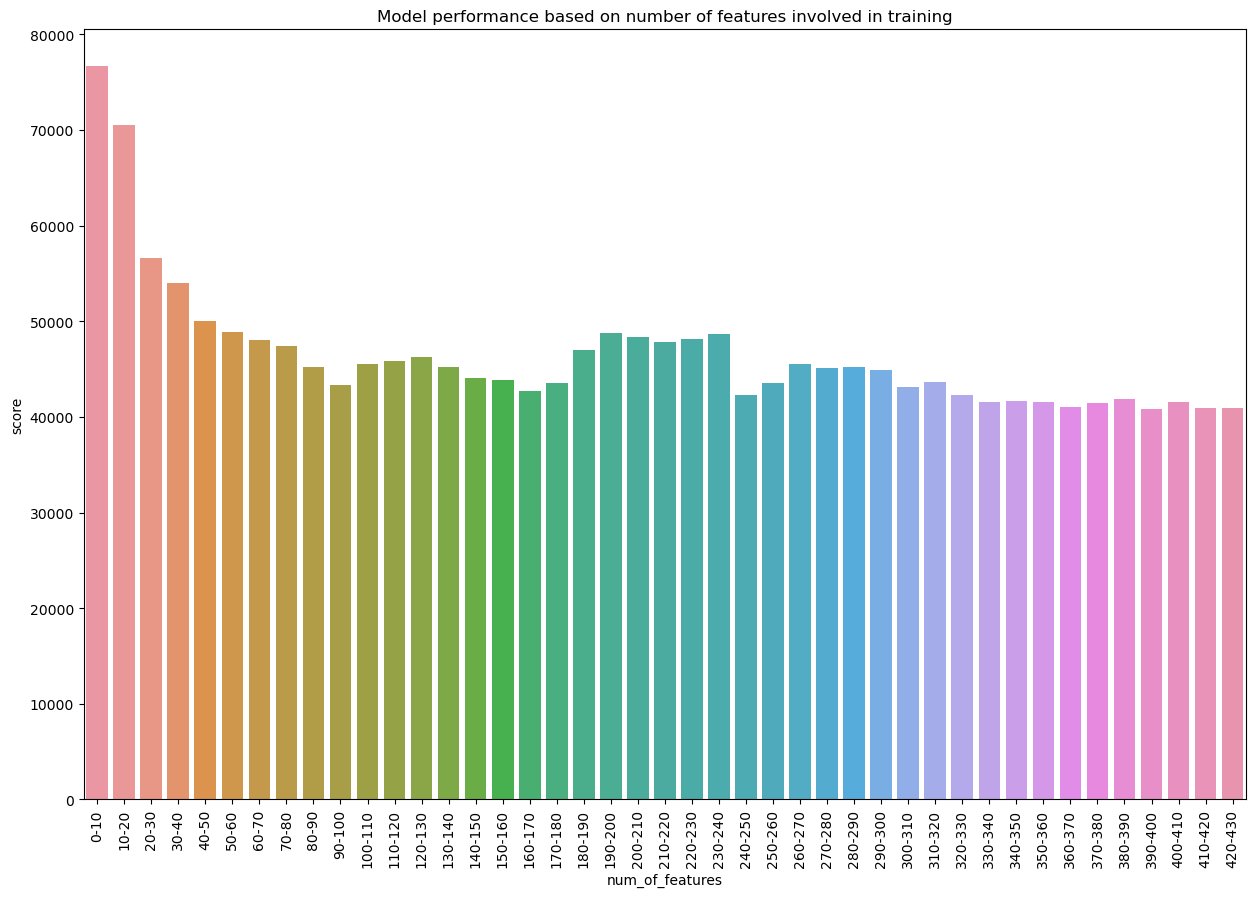

In [518]:
x = df_of_scores['num_of_features']
y = df_of_scores['score']
plt.figure(figsize=(15,10))
plt.xticks(rotation=90)
sns.barplot(x=x,y=y).set_title('Model performance based on number of features involved in training')

***Now we have to think about usefulness of reducing the number of features involved in training model***

# Recursive Feature Elimination

In [519]:
ridge_reg_params_ns2 = Ridge(alpha=6)

gbr_reg_params_ns2 = GradientBoostingRegressor(criterion='squared_error', max_depth=5,
                          max_features='sqrt', min_samples_leaf=2,
                          min_samples_split=5, n_estimators=300)

sgd_reg_params_ns2 = SGDRegressor(alpha=0.0003, epsilon=0.5, eta0=0.005, fit_intercept=False,
             l1_ratio=0.1, learning_rate='adaptive',
             loss='squared_epsilon_insensitive', max_iter=2000, penalty='l1',
             power_t=0.4)

In [520]:
#gbr_reg_params_ns2.fit(X_train,y_train)

In [521]:
#sgd_reg_params_ns2.fit(X_train,y_train)

In [522]:
#RFE_selector = RFE(estimator=sgd_reg_params_ns2, step=1)
#RFE_selector.fit(X_train, y_train)

In [524]:
#X_train.columns[RFE_selector.support_]

In [525]:
#columns_to_train = list(X_train.columns[RFE_selector.support_])

In [526]:
#final_train_features2 = final_train_data.drop('SalePrice', axis=1)
#final_train_features2 = final_train_features2[columns_to_train]
#final_train_target2 = final_train_data['SalePrice']

In [527]:
# final_model2 = VotingRegressor([('sgd',sgd_reg_params_ns),
#                            ('ridge', ridge_reg_params_ns),
#                            ('gbr', gbr_reg_params_ns),
#                            ('lgbm', lgbm_reg_params_ns)]
#                             )

In [528]:
#final_model2.fit(final_train_features2,final_train_target2)

In [529]:
#predictions2 = final_model2.predict(final_test_data[columns_to_train])

In [530]:
# output = pd.DataFrame({'Id': df_test.Id,
#                      'SalePrice': predictions2})
# output.to_csv('./v2_final_predictions5.csv', index=False)

In [531]:
#predictions2